# 02-2. 예측 모델 개발과 성능 평가

01-2 노트북에서 정한 두 가지 예측을 실제로 만들고 비교합니다. 보고서 **제2장 「AI 예측모델 개발 및 성능평가」**의 근거 자료입니다.

| | 하루 앞 예측 (주) | 1시간 앞 예측 (보조) |
|---|---|---|
| 언제 | 매일 자정 직전 | 매 정시 |
| 무엇을 | 다음 날 15분 전력 96칸 | 다음 1시간의 15분 전력 4칸 |
| 용도 | 생산 일정·가동 시점 조정 | 당일 피크 경보 |

모든 모델은 **같은 5주 시험 기간**에서, **각 주 이전 데이터로만 학습**해 비교합니다.

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../outputs/figures"); TAB_DIR = Path("../outputs/tables")
PRED_DIR = Path("../outputs/predictions"); PRED_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(fig, name): fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
def save_table(df, name): df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

slots = pd.read_csv("../data/processed/slots_15min.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")
slots["칸번호"] = (slots["시각"] * 4).astype(int)            # 0시 0분 = 0, ..., 23시 45분 = 95
slots["요일"] = slots.index.dayofweek
slots["하루종류코드"] = slots["하루종류"].map({"평일가동": 0, "토요일": 1, "휴일": 2})

TEST_STARTS = pd.to_datetime(["2021-08-09", "2021-08-16", "2021-08-23", "2021-08-30", "2021-09-06"])
TEST_ENDS = list(TEST_STARTS[1:]) + [pd.Timestamp("2021-09-15")]
HIGH = 178        # 고부하 기준: 측정 구간(7/1~9/14) 전체 15분 전력의 상위 10% (01-1 노트북 3-5)
SEED = 42
print(slots.shape, "| 시험 주:", [d.strftime("%m/%d") for d in TEST_STARTS])

(7296, 19) | 시험 주: ['08/09', '08/16', '08/23', '08/30', '09/06']


### 공통 도구: 평가 지표와 '우연인지' 확인하는 방법
- **평균 절대오차(MAE)**: 예측이 실제와 평균적으로 얼마나 차이 나는지 (작을수록 좋음)
- **고부하 구간 MAE**: 실제 전력이 178을 넘는 구간(상위 10%)에서의 오차
- **하루 최대 전력 오차**: 하루 중 가장 높은 값을 얼마나 맞혔는지 (요금과 직결)
- **주별 MAE 범위**: 5주 중 가장 좋았던 주 ~ 가장 나빴던 주의 MAE (결과가 주마다 얼마나 흔들리는지)

시험 기간은 37일뿐이라, 두 모델의 차이가 **실력 차이인지 우연인지** 확인해야 합니다.
그래서 **시험 날짜를 무작위로 다시 뽑아 오차 차이를 2,000번 다시 계산**합니다. 이런 방법을 부트스트랩이라고 합니다.
이렇게 얻은 95% 범위가 0을 포함하지 않으면 '우연이 아닌 차이'로 봅니다.

**지표 설명** (단위는 모두 kW, 상대오차만 %)
- **MAE**(평균 절대오차): 예측이 실제와 평균 몇 kW 차이 나는가. 이 노트북의 기본 지표입니다.
- **RMSE**: 큰 오차에 더 큰 벌점을 주는 지표. MAE보다 많이 크면 가끔 크게 틀린다는 뜻입니다.
- **상대오차(%)**: 오차의 합 ÷ 실제 전력의 합. 공장 규모가 다른 사례와 비교할 때 씁니다.
- **고부하 구간 MAE**: 실제 전력이 178을 넘은 칸만의 MAE. 단, 실제값이 높은 칸만 골라 보면 어떤 모델이든 낮게 예측한 것처럼 보입니다(평균으로의 회귀, 02-3 노트북). 그래서 모델 선택에는 쓰지 않고 참고로만 봅니다.

In [2]:
def evaluate(df, models, target="전력", ok="정답사용", daymax=True):
    d = df[df[ok]]
    rows = {}
    for m in models:
        err = (d[m] - d[target]).abs()
        weekly = err.groupby(d["시험주"]).mean()
        sq = (d[m] - d[target]) ** 2
        row = {"MAE": err.mean(), "RMSE": np.sqrt(sq.mean()),
               "상대오차(%)": 100 * err.sum() / d.loc[d[m].notna(), target].sum(),   # 오차 합 ÷ 실제 전력 합
               "고부하 구간 MAE": err[d[target] > HIGH].mean()}
        if daymax:
            row["하루 최대 전력 오차"] = (d.groupby("date")[m].max() - d.groupby("date")[target].max()).abs().mean()
        row["주별 MAE 범위"] = f"{weekly.min():.1f} ~ {weekly.max():.1f}"
        row["평가 칸 수"] = int(d[m].notna().sum())
        rows[m] = row
    out = pd.DataFrame(rows).T
    for c in ["MAE", "RMSE", "상대오차(%)", "고부하 구간 MAE", "하루 최대 전력 오차"]:
        if c in out: out[c] = out[c].astype(float).round(2)
    return out

def compare(df, best, others, target="전력", ok="정답사용", n_boot=2000):
    """날짜 단위 부트스트랩: (다른 모델 MAE − 기준 모델 MAE)와 95% 범위. 모든 모델이 예측한 칸만 사용"""
    d = df[df[ok]].dropna(subset=[best] + others)
    rng = np.random.default_rng(SEED)
    dates = d["date"].unique()
    g = d.groupby("date")
    cnt = g.size()
    sums = {m: (d[m] - d[target]).abs().groupby(d["date"]).sum() for m in [best] + others}
    rows = {}
    for m in others:
        diff_day = sums[m] - sums[best]
        idx = rng.integers(0, len(dates), size=(n_boot, len(dates)))
        boot = diff_day.values[idx].sum(1) / cnt.values[idx].sum(1)
        point = diff_day.sum() / cnt.sum()
        lo, hi = np.percentile(boot, [2.5, 97.5])
        rows[m] = {"MAE 차이 (다른 모델 − 기준)": round(point, 2), "95% 범위": f"{lo:.2f} ~ {hi:.2f}",
                   "판정": "기준 모델이 더 정확" if lo > 0 else ("다른 모델이 더 정확" if hi < 0 else "우연 범위 (차이 없음)")}
    return pd.DataFrame(rows).T

## 1. 하루 앞 예측

### 1-1. 비교할 모델
| 모델 | 설명 | 생산계획 사용 |
|---|---|---|
| ① 지난주 같은 시각 | 7일 전 같은 시각의 값을 그대로 씀 (가장 단순한 기준) | X |
| ② 최근 4주 같은 요일 | 최근 4주 같은 요일·시각 값의 중앙값 | X |
| ③ **계획 기반 기준 곡선** | 과거 데이터에서 '하루 종류 × 전날 가동 여부 × 시각'별 평균 전력 | O (가동 여부) |
| ④ LightGBM (달력+계획) | ③의 정보에 요일, 시간별·하루 계획 생산량을 더해 학습한 트리 모델 | O (가동 여부 + 계획량) |
| ⑤ LightGBM (+과거 전력) | ④에 어제·지난주 같은 시각 전력, 어제 평균 전력을 더함 | O (가동 여부 + 계획량) |
| ⑥ 기준 곡선 + LightGBM 보정 | ③의 곡선에서 벗어나는 정도를 ④의 입력으로 LightGBM이 학습해 더함 | O (가동 여부 + 계획량) |

③은 01-1 노트북의 핵심 발견(**전력은 '하루 종류 + 시각'으로 대부분 정해진다**)을 그대로 모델로 만든 것입니다.
LightGBM은 표 형태 데이터에서 널리 쓰이는 트리 기반 머신러닝 모델입니다.
기온은 미래 값을 알 수 없으므로 여기서는 쓰지 않고, 1-3에서 '예보가 정확하다면'이라는 가정으로 따로 실험합니다.

In [3]:
y = slots["전력"]
feat = slots.copy()
feat["어제같은시각"] = y.shift(96)
feat["지난주같은시각"] = y.shift(672)
feat["어제평균"] = slots.groupby("date")["전력"].transform("mean").shift(96)      # 전날 하루 평균
feat["4주같은요일중앙값"] = pd.concat([y.shift(672 * k) for k in range(1, 5)], axis=1).median(axis=1)

CURVE_KEYS = ["하루종류코드", "전날가동", "칸번호"]
def base_curve(train, keys=CURVE_KEYS):
    """기준 곡선: 학습 기간의 '하루 종류 × 전날 가동 × 시각'별 평균 전력"""
    return train[train["정답사용"]].groupby(keys)["전력"].mean().rename("기준곡선")

F_CAL = ["칸번호", "요일", "하루종류코드", "전날가동", "생산량", "일생산량"]
F_LAG = F_CAL + ["어제같은시각", "지난주같은시각", "어제평균"]
def lgbm(**kw):
    params = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=30,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1)
    params.update(kw)
    return lgb.LGBMRegressor(**params)

day_preds = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    train = feat[feat.index < st]
    test = feat[(feat.index >= st) & (feat.index < en)].copy()
    fit = train[train["정답사용"]]
    curve = base_curve(train)
    test["③ 계획 기반 기준 곡선"] = test.join(curve, on=CURVE_KEYS)["기준곡선"]
    fit_curve = fit.join(curve, on=CURVE_KEYS)["기준곡선"]

    test["① 지난주 같은 시각"] = test["지난주같은시각"]
    test["② 최근 4주 같은 요일"] = test["4주같은요일중앙값"]
    test["④ LightGBM (달력+계획)"] = lgbm().fit(fit[F_CAL], fit["전력"]).predict(test[F_CAL])
    test["⑤ LightGBM (+과거 전력)"] = lgbm().fit(fit[F_LAG], fit["전력"]).predict(test[F_LAG])
    res_model = lgbm(n_estimators=200, num_leaves=7, min_child_samples=50).fit(fit[F_CAL], fit["전력"] - fit_curve)
    test["⑥ 기준 곡선 + LightGBM 보정"] = test["③ 계획 기반 기준 곡선"] + res_model.predict(test[F_CAL])
    test["시험주"] = st.strftime("%m/%d")
    day_preds.append(test)
day_preds = pd.concat(day_preds)
DAY_MODELS = sorted(c for c in day_preds.columns if c[0] in "①②③④⑤⑥")
print("시험 칸:", day_preds["정답사용"].sum())

시험 칸: 3478


### 1-2. 성능 비교

In [4]:
day_table = evaluate(day_preds, DAY_MODELS)
save_table(day_table, "t10_하루앞_성능비교")
day_table

,MAE,RMSE,상대오차(%),고부하 구간 MAE,하루 최대 전력 오차,주별 MAE 범위,평가 칸 수
① 지난주 같은 시각,23.68,46.86,22.37,65.23,34.84,8.2 ~ 81.8,3406
② 최근 4주 같은 요일,9.16,13.95,8.79,11.78,11.85,7.2 ~ 11.2,3478
③ 계획 기반 기준 곡선,7.32,10.98,7.03,7.99,7.23,6.7 ~ 9.1,3478
④ LightGBM (달력+계획),8.94,12.95,8.58,10.42,9.53,8.0 ~ 11.6,3478
⑤ LightGBM (+과거 전력),10.84,16.30,10.41,21.42,13.49,7.9 ~ 20.0,3478
⑥ 기준 곡선 + LightGBM 보정,8.02,12.01,7.70,8.90,7.92,6.9 ~ 10.9,3478


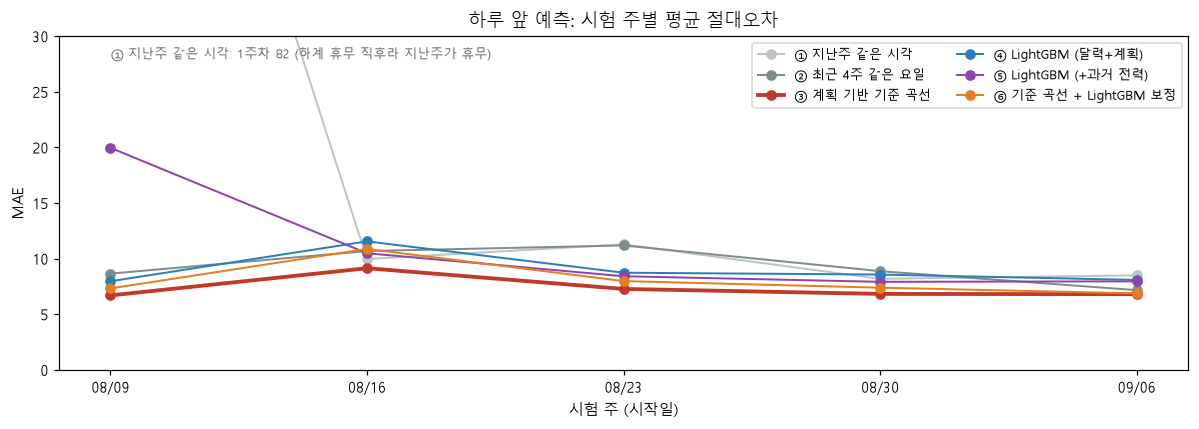

참고: 시험 기간에 '15분 전 값 그대로'를 쓰면 MAE 8.83
1주차(하계 휴무 직후)를 빼면: ① 9.40 → ③ 7.63 (19% 감소)


In [5]:
weekly = day_preds[day_preds["정답사용"]].groupby("시험주").apply(
    lambda g: pd.Series({m: (g[m] - g["전력"]).abs().mean() for m in DAY_MODELS}))
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#bdc3c7", "#7f8c8d", "#c0392b", "#2980b9", "#8e44ad", "#e67e22"]
for m, c in zip(DAY_MODELS, colors):
    ax.plot(weekly.index, weekly[m], marker="o", color=c, lw=2.5 if m.startswith("③") else 1.3, label=m)
ax.set_ylim(0, 30); ax.set_xlabel("시험 주 (시작일)"); ax.set_ylabel("MAE")
ax.text(0, 29, f"① 지난주 같은 시각: 1주차 {weekly['① 지난주 같은 시각'].iloc[0]:.0f} (하계 휴무 직후라 지난주가 휴무)", fontsize=8.5, color="dimgray", va="top")
ax.legend(fontsize=8.5, ncol=2, loc="upper right")
ax.set_title("하루 앞 예측: 시험 주별 평균 절대오차")
fig.tight_layout(); save_fig(fig, "f12_하루앞_주별오차"); plt.show()

# 비교를 위한 참고값: 시험 기간에 '15분 전 값 그대로'를 쓴 경우
test_mask = (slots.index >= TEST_STARTS[0]) & slots["정답사용"]
persist15 = (y - y.shift(1)).abs()[test_mask].mean()
w1 = day_preds[day_preds["시험주"] != "08/09"]
w1 = w1[w1["정답사용"] & w1["① 지난주 같은 시각"].notna()]
m1, m3 = [(w1[m] - w1["전력"]).abs().mean() for m in ["① 지난주 같은 시각", "③ 계획 기반 기준 곡선"]]
print(f"참고: 시험 기간에 '15분 전 값 그대로'를 쓰면 MAE {persist15:.2f}")
print(f"1주차(하계 휴무 직후)를 빼면: ① {m1:.2f} → ③ {m3:.2f} ({1 - m3 / m1:.0%} 감소)")

In [6]:
day_cmp = compare(day_preds, "③ 계획 기반 기준 곡선", [m for m in DAY_MODELS if not m.startswith("③")])
save_table(day_cmp, "t12_하루앞_차이검정")
day_cmp

,MAE 차이 (다른 모델 − 기준),95% 범위,판정
① 지난주 같은 시각,16.24,5.31 ~ 28.71,기준 모델이 더 정확
② 최근 4주 같은 요일,1.87,0.85 ~ 3.07,기준 모델이 더 정확
④ LightGBM (달력+계획),1.64,1.10 ~ 2.26,기준 모델이 더 정확
⑤ LightGBM (+과거 전력),3.57,1.73 ~ 5.83,기준 모델이 더 정확
⑥ 기준 곡선 + LightGBM 보정,0.71,0.31 ~ 1.20,기준 모델이 더 정확


**해석**
- **③ 계획 기반 기준 곡선의 평균 오차가 가장 작습니다**(MAE 7.32). 5주 모두 6.7~9.1로 흔들림도 가장 적습니다.
  하루 전에 예측했는데도, 같은 시험 기간에 '15분 전 값을 그대로' 쓴 경우(MAE 8.83)보다 오차가 작습니다.
  **내일 공장을 어떻게 돌릴지(가동 계획)만 알면 하루 전에도 충분히 정확하게 예측할 수 있다**는 뜻입니다.
- 날짜를 다시 뽑아 확인해도 **③은 다른 다섯 모델보다 모두 정확**합니다(표의 95% 범위가 모두 0보다 큼).
- ① 지난주 같은 시각은 하계 휴무 직후(1주차)에 오차가 80을 넘습니다. 지난주가 휴무였기 때문입니다.
  전체로는 ③이 69% 더 정확하지만 이 한 주의 영향이 크고, **1주차를 빼면 약 19% 더 정확**합니다(① 9.40 → ③ 7.63).
- ② 최근 4주 같은 요일(9.16)은 요일만 보고 가동 계획은 보지 않아서, 휴무가 섞인 기간에 흔들립니다.
- ④·⑤ LightGBM은 ③보다 **더 많은 정보를 쓰고도 오차가 더 큽니다**. 어떤 정보가 해가 되는지는 1-3에서 확인합니다.
- ⑥ 기준 곡선에 LightGBM 보정을 더해도 오히려 나빠집니다(8.02). 보정에 쓰는 입력에 계획 생산량이 들어 있기 때문입니다(1-3).

### 1-3. 어떤 정보가 예측에 도움이 되나?
입력 정보를 하나씩 바꿔 가며 같은 방식으로 평가합니다. 같은 LightGBM 설정에서 입력만 바꾸고, LightGBM이 매번 입력 일부만 무작위로 골라 쓰는 기능을 꺼서, 입력 차이만 비교되게 했습니다.

| 실험 | 내용 |
|---|---|
| (가) 달력만으로 만든 기준 곡선 | 생산계획 없이 **달력**(일요일·공휴일 = 쉬는 날)으로 하루 종류를 정함 → 하계 휴무를 모름 |
| (나) 계획 기반 기준 곡선 | ③과 같음 (생산계획으로 가동 여부를 정함) |
| (다)~(바) LightGBM | 기준 곡선과 같은 정보에서 시작해 계획 생산량을 하나씩 더함 |
| (사) 기준 곡선 + 기온 보정 | 평일 주간에 기온에 따른 차이를 더함. 실제 기온을 쓰므로 **'기온 예보가 정확하다면'** 얻을 수 있는 최대 효과 |

In [7]:
HOLIDAYS = pd.to_datetime(["2021-08-15", "2021-08-16"])          # 측정 구간의 공휴일 (8/16 광복절 대체공휴일)
cal_day = pd.Series(slots["date"].unique())
cal_type = np.where(cal_day.dt.dayofweek.eq(6) | cal_day.isin(HOLIDAYS), 2, np.where(cal_day.dt.dayofweek.eq(5), 1, 0))
cal = pd.DataFrame({"달력종류코드": cal_type}, index=cal_day)
cal["달력전날가동"] = pd.Series(cal_type != 2, index=cal_day).shift(1, fill_value=True)
feat = feat.join(cal, on="date")
CAL_KEYS = ["달력종류코드", "달력전날가동", "칸번호"]

KEY_F = ["하루종류코드", "전날가동", "칸번호"]
ablation_sets = {
    "(다) LightGBM: 기준 곡선과 같은 정보": KEY_F,
    "(라) LightGBM: + 시간별 계획 생산량": KEY_F + ["생산량"],
    "(마) LightGBM: + 하루 계획 생산량": KEY_F + ["일생산량"],
    "(바) LightGBM: + 요일·시간별·하루 계획 생산량 (④와 같은 입력)": F_CAL,
}
abl = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    train = feat[feat.index < st]
    test = feat[(feat.index >= st) & (feat.index < en)].copy()
    fit = train[train["정답사용"]]
    test["(가) 달력만으로 만든 기준 곡선"] = test.join(base_curve(train, CAL_KEYS), on=CAL_KEYS)["기준곡선"]
    curve = base_curve(train)
    test["(나) 계획 기반 기준 곡선 (③)"] = test.join(curve, on=CURVE_KEYS)["기준곡선"]
    for name, F in ablation_sets.items():
        test[name] = lgbm(colsample_bytree=1.0).fit(fit[F], fit["전력"]).predict(test[F])
    # (사) 평일 주간(08~19시)에 기온 효과를 더함. 01-1 노트북의 기온 분석 구간(화~금 09~16시)보다 넓게 적용
    day_mask = lambda d: ((d["하루종류코드"] == 0) & d.index.hour.isin(range(8, 20))).astype(float)
    fit_res = fit["전력"] - fit.join(curve, on=CURVE_KEYS)["기준곡선"]
    X = lambda d: np.c_[d["기온"] * day_mask(d), day_mask(d)]
    temp_model = Ridge(alpha=1.0).fit(X(fit), fit_res)
    test["(사) 기준 곡선 + 기온 보정 (예보가 정확하다고 가정)"] = test["(나) 계획 기반 기준 곡선 (③)"] + temp_model.predict(X(test))
    test["시험주"] = st.strftime("%m/%d")
    abl.append(test)
abl = pd.concat(abl)
ABL = sorted(c for c in abl.columns if c.startswith("("))
abl_table = evaluate(abl, ABL)[["MAE", "고부하 구간 MAE", "하루 최대 전력 오차", "주별 MAE 범위"]]
save_table(abl_table, "t13_입력정보_실험")

wd = slots[(slots["하루종류"] == "평일가동") & slots["정답사용"] & (slots.index.dayofweek > 0)]
wd_day = wd.groupby("date").agg(평균전력=("전력", "mean"), 일생산량=("일생산량", "first"))
print(f"참고: 화~금 가동일의 '하루 계획 생산량'과 '하루 평균 전력'의 상관계수 = {wd_day['평균전력'].corr(wd_day['일생산량']):.2f}")
abl_table

참고: 화~금 가동일의 '하루 계획 생산량'과 '하루 평균 전력'의 상관계수 = -0.16


,MAE,고부하 구간 MAE,하루 최대 전력 오차,주별 MAE 범위
(가) 달력만으로 만든 기준 곡선,14.47,32.62,26.25,10.4 ~ 19.5
(나) 계획 기반 기준 곡선 (③),7.32,7.99,7.23,6.7 ~ 9.1
(다) LightGBM: 기준 곡선과 같은 정보,7.47,8.08,7.85,6.8 ~ 9.4
(라) LightGBM: + 시간별 계획 생산량,8.41,9.18,8.42,7.3 ~ 10.5
(마) LightGBM: + 하루 계획 생산량,9.19,9.94,10.63,7.8 ~ 11.6
(바) LightGBM: + 요일·시간별·하루 계획 생산량 (④와 같은 입력),9.37,10.74,9.54,8.0 ~ 12.4
(사) 기준 곡선 + 기온 보정 (예보가 정확하다고 가정),7.23,8.87,7.64,6.6 ~ 8.4


**해석**
- **생산계획의 '가동 여부'는 큰 도움이 됩니다.** 달력만으로 하루 종류를 정하면(가) 하계 휴무를 평일로 착각해 오차가 커집니다. 생산계획으로 정하면(나) 크게 줄어듭니다.
- **LightGBM도 기준 곡선과 같은 정보만 주면 거의 같은 성능**을 냅니다(다). 모델이 나빠서가 아닙니다.
- **문제는 '계획 생산량'입니다.** 시간별(라)·하루(마) 계획량을 더할수록 오차가 커집니다.
  01-1 노트북에서 본 것처럼 **가동일끼리는 계획량이 많다고 전기를 더 쓰지 않기** 때문에(화~금 가동일 기준 상관 −0.16, 관계 없음. 01-1 노트북의 −0.18과 조금 다른 것은 여기서는 복사 의심일 7/28·7/30을 뺐기 때문입니다), 모델이 의미 없는 관계를 배우게 됩니다.
- **기온 예보가 정확하다고 가정해도 이득은 작습니다**(사). 평균 오차는 아주 조금 줄지만(7.32 → 7.23) 고부하 구간 오차는 오히려 커집니다(7.99 → 8.87).
  기온 효과(1℃당 약 1.7)가 15분 단위의 흔들림에 비해 작기 때문입니다. 그래서 기온은 최종 모델에 넣지 않습니다.

→ 하루 앞 예측에 필요한 정보는 **'내일 가동하는가' + '오늘 가동했는가' + 시각**이고, 이를 가장 간단하게 담은 것이 ③ 기준 곡선입니다.

### 1-4. 예측 곡선 예시
평범한 주와 어려운 주(8/16 대체공휴일 가동)를 하나씩 봅니다.

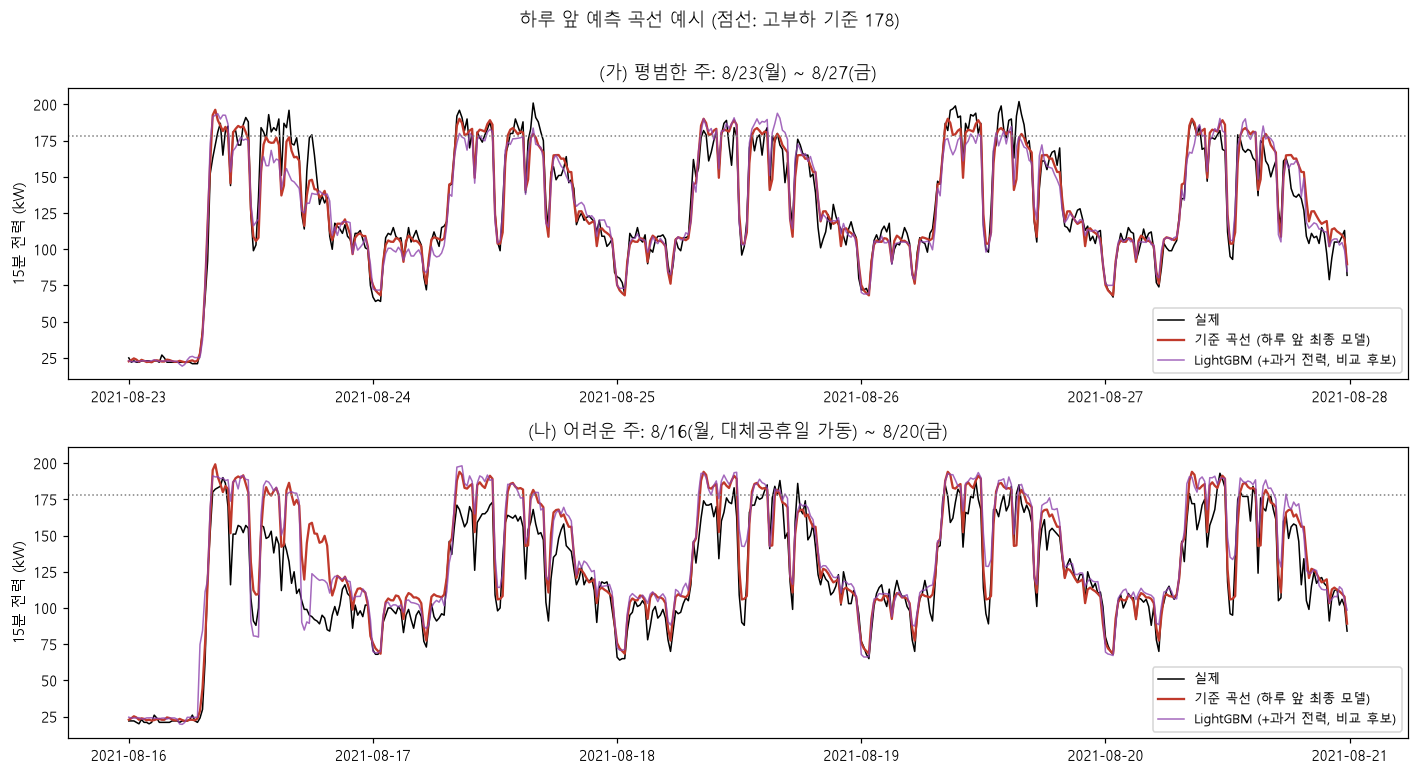

주간(08~16시) 실제 − 예측 평균: {'08/16': -26.8, '08/17': -17.3, '08/18': -9.8, '08/19': -7.7, '08/20': -7.5}
하루 계획 생산량: {'08/16': 10238, '08/17': 29279, '08/18': 20063, '08/19': 25976, '08/20': 25213}


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharey=True)
for ax, (s, e, title) in zip(axes, [("2021-08-23", "2021-08-27 23:45", "(가) 평범한 주: 8/23(월) ~ 8/27(금)"),
                                     ("2021-08-16", "2021-08-20 23:45", "(나) 어려운 주: 8/16(월, 대체공휴일 가동) ~ 8/20(금)")]):
    d = day_preds.loc[s:e]
    ax.plot(d.index, d["전력"], color="black", lw=1, label="실제")
    ax.plot(d.index, d["③ 계획 기반 기준 곡선"], color="#c0392b", lw=1.5, label="기준 곡선 (하루 앞 최종 모델)")
    ax.plot(d.index, d["⑤ LightGBM (+과거 전력)"], color="#8e44ad", lw=1, alpha=0.8, label="LightGBM (+과거 전력, 비교 후보)")
    ax.axhline(HIGH, color="gray", ls=":", lw=1)
    ax.set_title(title); ax.set_ylabel("15분 전력 (kW)"); ax.legend(fontsize=8.5, loc="lower right")
fig.suptitle("하루 앞 예측 곡선 예시 (점선: 고부하 기준 178)", y=1.0)
fig.tight_layout(); save_fig(fig, "f13_하루앞_예측곡선"); plt.show()

d = day_preds.loc["2021-08-16":"2021-08-20 23:45"]
d = d[d["정답사용"] & d.index.hour.isin(range(8, 17))]
gap = (d["전력"] - d["③ 계획 기반 기준 곡선"]).groupby(d["date"]).mean()
print("주간(08~16시) 실제 − 예측 평균:", {k.strftime("%m/%d"): round(v, 1) for k, v in gap.items()})
print("하루 계획 생산량:", {k.strftime("%m/%d"): int(v) for k, v in d.groupby("date")["일생산량"].first().items()})

**해석**
- **평범한 주(가)**: 기준 곡선이 월요일 08시 가동 시작, 점심·휴식 시간의 하락, 야간 전환까지 실제 곡선을 그대로 따라갑니다.
- **어려운 주(나)**: 8/16(대체공휴일)은 오전에는 평소처럼 가동했지만 오후부터 전력이 크게 낮습니다(주간 평균 약 27 낮음). 8/17~8/20도 주간 전력이 평소보다 약 8~17 낮습니다.
  8/16은 계획 생산량이 평소의 절반 정도여서 신호가 있었습니다. 하지만 1-3에서 본 것처럼 계획량을 입력에 넣으면 전체 성능은 오히려 나빠집니다. 8/17~8/20은 계획량도 평소와 같았습니다.
  이렇게 **'평소보다 덜 돌린 날'은 전날 정보만으로 맞히기 어렵습니다.**
  → 당일 실제 전력을 보며 예측을 고치는 **1시간 앞 예측**이 필요한 이유입니다.

## 2. 1시간 앞 예측

### 2-1. 비교할 모델
매 정시에 **직전 15분까지의 기록**을 보고 다음 1시간(15분 칸 4개)을 예측합니다.

이 절의 번호(①~⑤)는 1절 하루 앞 예측의 번호와 별개입니다.

| 모델 | 설명 |
|---|---|
| ① 직전 값 그대로 | 마지막으로 기록된 15분 전력을 다음 1시간에 그대로 씀 |
| ② 계획 기반 기준 곡선 | 하루 앞 예측의 ③과 같음 (실시간 정보 없음) |
| ③ 기준 곡선 + 현재 편차 | 기준 곡선에 '지금 실제가 곡선보다 얼마나 높거나 낮은가'를 더함. 먼 시각일수록 편차를 줄여서 더함 |
| ④ **선형 회귀 (Ridge)** | 직전 값, 기준 곡선, 편차를 입력으로, 각각을 얼마나 믿을지(가중치)를 데이터에서 학습 |
| ⑤ LightGBM | 직전 4칸, 기준 곡선, 편차, 시각·하루 종류, 생산계획을 입력으로 학습 |

③에서 **편차를 얼마나 빨리 줄일지**는 각 시험 주마다 **학습 기간의 마지막 1주**로 시험해 보고 고릅니다(후보: 1, 2, 4, 8칸에 걸쳐 줄임). 시험 주의 결과는 보지 않습니다.

In [9]:
def hour_ahead_table(src):
    """매 정시 발행: 대상 = 그 시각부터 4칸, 입력 = 직전 15분까지"""
    yy = src["전력"]
    parts = []
    for step in range(4):
        d = pd.DataFrame(index=src.index)
        d["몇번째칸"] = step + 1
        d["대상시각"] = src.index + pd.Timedelta(minutes=15 * step)
        d["정답"] = yy.shift(-step)
        d["정답사용"] = src["정답사용"].shift(-step).fillna(False).astype(bool)
        for c in ["칸번호", "하루종류코드", "전날가동", "요일"]:
            d["대상_" + c] = src[c].astype(float).shift(-step)
        d["생산량"] = src["생산량"]
        for L in range(1, 5):
            d[f"직전{L}"] = yy.shift(L)
        parts.append(d[d.index.minute == 0])
    out = pd.concat(parts).dropna(subset=["대상_칸번호"])
    return out[out.index > "2021-07-01"]

def add_curve(d, curve):
    d = d.copy()
    d["곡선_대상"] = d.join(curve, on=["대상_하루종류코드", "대상_전날가동", "대상_칸번호"])["기준곡선"].values
    prev = slots.loc[d.index - pd.Timedelta(minutes=15), CURVE_KEYS]
    d["곡선_직전"] = prev.join(curve, on=CURVE_KEYS)["기준곡선"].values
    d["편차"] = d["직전1"] - d["곡선_직전"]
    return d

def curve_plus_dev(d, tau):
    return d["곡선_대상"] + d["편차"] * np.exp(-d["몇번째칸"] / tau)

H = hour_ahead_table(slots)
F_H = ["몇번째칸", "대상_칸번호", "대상_하루종류코드", "대상_전날가동", "대상_요일", "생산량",
       "직전1", "직전2", "직전3", "직전4", "곡선_대상", "곡선_직전", "편차"]
TAUS = [1, 2, 4, 8]
chosen_tau = {}
hour_preds = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    # (1) 편차 줄이는 속도: 학습 기간의 마지막 1주로 고름
    vst = st - pd.Timedelta(days=7)
    v = add_curve(H[(H.index >= vst) & (H.index < st)], base_curve(slots[slots.index < vst]))
    v = v[v["정답사용"] & v["직전1"].notna()]
    tau = min(TAUS, key=lambda t: (curve_plus_dev(v, t) - v["정답"]).abs().mean())
    chosen_tau[st.strftime("%m/%d")] = tau
    # (2) 시험 주 이전 전체로 학습, 시험 주 예측
    curve = base_curve(slots[slots.index < st])
    train = add_curve(H[H.index < st], curve)
    test = add_curve(H[(H.index >= st) & (H.index < en)], curve)
    fit = train[train["정답사용"] & train["직전1"].notna()]
    test["① 직전 값 그대로"] = test["직전1"]
    test["② 계획 기반 기준 곡선"] = test["곡선_대상"]
    test["③ 기준 곡선 + 현재 편차"] = curve_plus_dev(test, tau)
    lin_f = ["직전1", "곡선_대상", "곡선_직전", "편차"]
    test["④ 선형 회귀 (Ridge)"] = Ridge(alpha=1.0).fit(fit[lin_f].fillna(0), fit["정답"]).predict(test[lin_f].fillna(0))
    test["⑤ LightGBM"] = lgbm(n_estimators=500).fit(fit[F_H], fit["정답"]).predict(test[F_H])
    test["시험주"] = st.strftime("%m/%d")
    hour_preds.append(test)
hour_preds = pd.concat(hour_preds)
hour_preds = hour_preds[hour_preds["직전1"].notna()]
hour_preds["date"] = hour_preds["대상시각"].dt.normalize()
HOUR_MODELS = sorted(c for c in hour_preds.columns if c[0] in "①②③④⑤")
print("시험 주별로 고른 편차 줄이는 속도:", chosen_tau)

hour_table = evaluate(hour_preds, HOUR_MODELS, target="정답", daymax=False)
by_step = hour_preds[hour_preds["정답사용"]].groupby("몇번째칸").apply(
    lambda g: pd.Series({m: (g[m] - g["정답"]).abs().mean() for m in HOUR_MODELS})).T.round(2)
by_step.columns = ["첫 15분", "15~30분", "30~45분", "45~60분"]
hour_table = hour_table.join(by_step)
save_table(hour_table, "t11_1시간앞_성능비교")
hour_table

시험 주별로 고른 편차 줄이는 속도: {'08/09': 1, '08/16': 2, '08/23': 8, '08/30': 4, '09/06': 2}


,MAE,RMSE,상대오차(%),고부하 구간 MAE,주별 MAE 범위,평가 칸 수,첫 15분,15~30분,30~45분,45~60분
① 직전 값 그대로,14.48,23.59,13.90,22.56,13.0 ~ 15.5,3476,12.90,14.81,14.73,15.50
② 계획 기반 기준 곡선,7.32,10.98,7.02,7.99,6.7 ~ 9.1,3476,6.98,7.48,7.23,7.59
③ 기준 곡선 + 현재 편차,6.35,9.51,6.10,7.84,6.0 ~ 7.3,3476,5.01,6.48,6.72,7.19
④ 선형 회귀 (Ridge),6.26,9.12,6.01,8.33,6.0 ~ 6.9,3476,5.11,6.41,6.53,7.00
⑤ LightGBM,6.52,9.56,6.26,9.07,5.9 ~ 7.5,3476,5.53,6.75,6.72,7.10


In [10]:
hour_cmp = compare(hour_preds, "④ 선형 회귀 (Ridge)", [m for m in HOUR_MODELS if not m.startswith("④")], target="정답")   # 기준 = 최종 모델
save_table(hour_cmp, "t14_1시간앞_차이검정")

change = (y - y.shift(1)).abs()[test_mask]
by_min = change.groupby(change.index.minute).mean()
print("시험 기간, 바로 앞 15분 대비 변화량 평균 — 정시 칸: "
      f"{by_min[0]:.1f}, 나머지 칸: {by_min.drop(0).min():.1f} ~ {by_min.drop(0).max():.1f}")
hour_cmp

시험 기간, 바로 앞 15분 대비 변화량 평균 — 정시 칸: 12.9, 나머지 칸: 6.7 ~ 8.3


,MAE 차이 (다른 모델 − 기준),95% 범위,판정
① 직전 값 그대로,8.22,6.75 ~ 9.62,기준 모델이 더 정확
② 계획 기반 기준 곡선,1.05,0.56 ~ 1.59,기준 모델이 더 정확
③ 기준 곡선 + 현재 편차,0.09,-0.08 ~ 0.27,우연 범위 (차이 없음)
⑤ LightGBM,0.26,0.06 ~ 0.46,기준 모델이 더 정확


**해석**
- **① 직전 값 그대로**는 오차가 14.48로 매우 큽니다. 가동 시작(08시), 점심(12시), 재가동(13시), 저녁(17시)처럼 **전력이 크게 바뀌는 순간이 정시에 몰려** 있어서(위 변화량 참고: 정시 칸 12.9, 나머지 6.7~8.3), 정시 직전 값이 다음 1시간을 대표하지 못합니다.
- **현재 상황을 반영하면 기준 곡선보다 정확해집니다.** ③ 기준 곡선 + 현재 편차는 6.35, ④ 선형 회귀는 6.26으로, 기준 곡선만 쓸 때(7.32)보다 13~14% 줄었습니다. 특히 첫 15분의 오차가 크게 줄었습니다.
  '오늘은 평소보다 낮게 돌고 있다'(예시)는 정보를 쓰기 때문입니다.
- 위 표는 최종 모델인 ④를 기준으로 비교한 것입니다. **사람이 정한 규칙(③)과 데이터로 가중치를 학습한 선형 회귀(④)는 같은 수준**입니다(차이가 우연 범위). 더 많은 입력을 쓴 LightGBM(⑤)은 ④보다 조금 덜 정확합니다.
- 다만 **고부하 구간**(178 초과)에서는 이득이 거의 없거나(③ 7.84) 오히려 조금 커집니다(④ 8.33, 기준 곡선만 쓸 때 7.99). 피크 순간의 오차는 다음 단계(오류 분석)에서 따로 봅니다.

→ 여기까지의 후보 중에서는 **④ 선형 회귀**가 가장 좋습니다. 평균 오차가 가장 작고, 학습한 가중치를 보면 예측이 어떻게 만들어지는지 설명할 수 있습니다(아래). 3절에서 Chronos-2와 결합해 최종 모델을 다시 정합니다.

In [11]:
# 최종 모델(④ 선형 회귀)의 가중치 — 마지막 시험 주(9/6~) 직전까지의 데이터로 학습한 모델
st = TEST_STARTS[-1]
curve = base_curve(slots[slots.index < st])
fit = add_curve(H[H.index < st], curve)
fit = fit[fit["정답사용"] & fit["직전1"].notna()]
lin_f = ["직전1", "곡선_대상", "곡선_직전", "편차"]
ridge = Ridge(alpha=1.0).fit(fit[lin_f].fillna(0), fit["정답"])
coef = pd.Series(ridge.coef_, index=["직전 15분 전력", "대상 시각의 기준 곡선", "직전 시각의 기준 곡선", "편차 (직전 전력 − 직전 곡선)"]).round(3)
print("상수항:", round(ridge.intercept_, 2))
a_last, a_curve_t, a_curve_prev, a_dev = ridge.coef_
print(f"합쳐서 정리하면: 예측 ≈ {a_curve_t:.2f} × 대상 시각의 기준 곡선 + {a_last + a_dev:.2f} × (직전 전력 − 직전 시각의 기준 곡선)")
coef.to_frame("가중치")

상수항: 0.02
합쳐서 정리하면: 예측 ≈ 1.00 × 대상 시각의 기준 곡선 + 0.53 × (직전 전력 − 직전 시각의 기준 곡선)


,가중치
직전 15분 전력,0.176
대상 시각의 기준 곡선,0.999
직전 시각의 기준 곡선,-0.174
편차 (직전 전력 − 직전 곡선),0.350


**가중치 읽는 법**: 입력 사이에 '직전 전력 = 직전 곡선 + 편차'라는 관계가 있어서 가중치를 하나씩 따로 해석하면 안 됩니다. 위처럼 합쳐서 보면,
**예측 ≈ 대상 시각의 기준 곡선 + 현재 편차의 약 절반**입니다.
즉 학습된 모델도 ③과 같은 구조('기준 곡선 + 현재 편차')를 데이터에서 스스로 찾아냈고, 편차를 얼마나 믿을지(약 절반)를 정해 준 것입니다.

## 3. 추가 모델 후보 비교

1~2절의 결과를 바탕으로, 사전 조사 자료와 추가 조사(README의 참고문헌)에서 나온 후보를 **같은 5주 시험**으로 비교합니다.

| 후보 | 쉬운 설명 | 왜 시도했나 |
|---|---|---|
| 중앙값 기준 곡선 | 기준 곡선을 평균 대신 중앙값으로 만듦 | 평균 절대오차에는 이론상 중앙값이 더 맞음 |
| 기준 곡선 + LightGBM 단순 평균 | 같은 정보만 쓴 두 모델의 예측을 반반 섞음 | 데이터가 적을 때는 단순 평균이 강하다는 연구 결과 |
| **Chronos-2** (3가지 방식) | 수많은 시계열로 미리 학습된 예측 모델. 우리 데이터로 따로 학습하지 않음 (02-1 노트북) | 최신 시계열 파운데이션 모델과 비교 |
| 기준 곡선 + Chronos-2 평균 (하루 앞) | 두 예측을 반반 섞음 | 성격이 다른 두 모델의 실수가 서로 상쇄되는지 |
| 칼만 필터 보정 (1시간 앞) | '오늘은 평소보다 얼마나 높게/낮게 도는가'를 15분마다 조금씩 갱신 | 평소보다 덜 돌린 날을 겨냥 |
| **선형 회귀 + Chronos-2 평균** (1시간 앞) | 두 예측을 반반 섞음 | 위와 같음 |

TabPFN은 무료로 쓸 수 있는 버전의 권장 데이터 크기(CPU 기준 1,000행 이하)를 우리 데이터가 넘고, 최신 버전은 비상업 라이선스라 제외했습니다.

In [12]:
# Chronos-2 예측 불러오기 (02-1 노트북에서 만든 파일)
chronos_day_path = PRED_DIR / "chronos_day_ahead.csv"
chronos_hour_path = PRED_DIR / "chronos_hour_ahead.csv"
assert chronos_day_path.exists() and chronos_hour_path.exists(), "02-1_사전학습모델_Chronos2.ipynb를 먼저 실행하세요."
c_day = pd.read_csv(chronos_day_path, encoding="utf-8-sig", parse_dates=["ts"]).pivot(index="ts", columns="모델", values="예측")
c_hour = pd.read_csv(chronos_hour_path, encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])

# ---------- 하루 앞 ----------
cand_day = day_preds[["date", "시험주", "전력", "정답사용", "③ 계획 기반 기준 곡선", "② 최근 4주 같은 요일", "① 지난주 같은 시각"]].copy()
cand_day = cand_day.rename(columns={"③ 계획 기반 기준 곡선": "기준 곡선 (최종)"})
extra = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    train = feat[feat.index < st]
    test = feat[(feat.index >= st) & (feat.index < en)].copy()
    fit = train[train["정답사용"]]
    med = fit.groupby(CURVE_KEYS)["전력"].median().rename("x")
    test["중앙값 기준 곡선"] = test.join(med, on=CURVE_KEYS)["x"]
    test["LightGBM (같은 정보)"] = lgbm(colsample_bytree=1.0).fit(fit[KEY_F], fit["전력"]).predict(test[KEY_F])
    extra.append(test[["중앙값 기준 곡선", "LightGBM (같은 정보)"]])
cand_day = cand_day.join(pd.concat(extra)).join(c_day)
cand_day["기준 곡선 + LightGBM 평균"] = (cand_day["기준 곡선 (최종)"] + cand_day["LightGBM (같은 정보)"]) / 2
cand_day["기준 곡선 + Chronos-2 평균"] = (cand_day["기준 곡선 (최종)"] + cand_day["Chronos-2 (+가동 계획)"]) / 2
CAND_DAY = ["기준 곡선 (최종)", "중앙값 기준 곡선", "기준 곡선 + LightGBM 평균",
            "Chronos-2 (기록만)", "Chronos-2 (+가동 계획)", "Chronos-2 (+기준 곡선)", "기준 곡선 + Chronos-2 평균"]
cand_day_table = evaluate(cand_day, CAND_DAY).drop(columns="평가 칸 수")
cand_day_table = cand_day_table.join(compare(cand_day, "기준 곡선 (최종)", CAND_DAY[1:]).rename(
    columns={"MAE 차이 (다른 모델 − 기준)": "최종 모델과 MAE 차이"}))
save_table(cand_day_table, "t15_하루앞_추가후보")
cand_day_table

,MAE,RMSE,상대오차(%),고부하 구간 MAE,하루 최대 전력 오차,주별 MAE 범위,최종 모델과 MAE 차이,95% 범위,판정
기준 곡선 (최종),7.32,10.98,7.03,7.99,7.23,6.7 ~ 9.1,NaN,NaN,NaN
중앙값 기준 곡선,7.44,11.26,7.14,7.84,7.01,6.7 ~ 9.3,0.12,0.04 ~ 0.21,기준 모델이 더 정확
기준 곡선 + LightGBM 평균,7.34,10.97,7.04,7.95,7.59,6.6 ~ 9.2,0.02,-0.03 ~ 0.06,우연 범위 (차이 없음)
Chronos-2 (기록만),8.67,18.06,8.33,19.03,12.11,6.2 ~ 14.2,1.35,-0.66 ~ 4.77,우연 범위 (차이 없음)
Chronos-2 (+가동 계획),7.54,11.32,7.24,10.98,8.72,6.7 ~ 9.3,0.22,-0.48 ~ 1.05,우연 범위 (차이 없음)
Chronos-2 (+기준 곡선),7.74,11.89,7.43,10.40,7.85,6.7 ~ 10.3,0.42,-0.28 ~ 1.26,우연 범위 (차이 없음)
기준 곡선 + Chronos-2 평균,7.10,10.72,6.81,9.09,7.36,6.3 ~ 8.3,-0.22,-0.59 ~ 0.20,우연 범위 (차이 없음)


**해석 (하루 앞)**
- **기준 곡선을 넘는 후보는 없었습니다.** 표의 '최종 모델과 MAE 차이'가 음수이면서 95% 범위가 0을 포함하지 않는 후보가 없습니다.
- **기준 곡선 + Chronos-2 평균**은 평균 오차가 7.10으로 가장 작지만, 차이가 우연 범위(−0.59 ~ 0.20)입니다. 게다가 **고부하 구간 오차가 7.99에서 9.09로 커집니다.** 피크를 미리 아는 것이 목적이므로 기준 곡선을 그대로 최종 모델로 둡니다.
- Chronos-2는 **우리 데이터로 학습하지 않았는데도** 가동 계획만 주면 7.54로, LightGBM(8.94)보다 정확합니다. 사전학습 모델의 힘을 보여 주지만, 피크 구간(10.98)에서는 기준 곡선(7.99)에 크게 못 미칩니다.
- 중앙값 기준 곡선은 오히려 조금 나빴고(우연이 아닌 차이), LightGBM과의 단순 평균은 사실상 같았습니다.

In [13]:
# ---------- 1시간 앞 ----------
cand_hour = hour_preds.reset_index().rename(columns={"index": "발행시각", "ts": "발행시각"})
cand_hour = cand_hour.merge(c_hour[["발행시각", "대상시각", "예측"]].rename(columns={"예측": "Chronos-2 (+가동 계획)"}),
                            on=["발행시각", "대상시각"], how="left")
assert cand_hour["Chronos-2 (+가동 계획)"].notna().all()

# 칼만 필터 보정: 기준 곡선과의 차이(편차)를 '천천히 변하는 수준'으로 보고 15분마다 갱신
def kalman_level(dev, rho, q, r=1.0):
    a, P, out = 0.0, 1.0, np.empty(len(dev))
    for i, e in enumerate(dev):
        a, P = rho * a, rho * rho * P + q                # 예측 단계: 수준은 조금씩 0으로 돌아감
        if not np.isnan(e):                              # 관측이 있으면 갱신
            gain = P / (P + r); a += gain * (e - a); P *= (1 - gain)
        out[i] = a
    return pd.Series(out, index=dev.index)

def kalman_pred(curve, issues, rho, q):
    dev = slots["전력"] - slots.join(curve, on=CURVE_KEYS)["기준곡선"]
    level = kalman_level(dev, rho, q)
    d = H.loc[H.index.isin(issues)].copy()
    tgt_curve = d.join(curve, on=["대상_하루종류코드", "대상_전날가동", "대상_칸번호"])["기준곡선"].values
    last_level = level.loc[d.index - pd.Timedelta(minutes=15)].values
    d["칼만"] = tgt_curve + last_level * rho ** d["몇번째칸"].values
    return d

GRID = [(r, q) for r in [0.8, 0.9, 0.95, 0.98] for q in [0.05, 0.2, 1.0, 5.0]]
kal = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    vst = st - pd.Timedelta(days=7)                      # 설정값은 학습 기간 마지막 1주로 고름
    vcurve = base_curve(slots[slots.index < vst])
    vissues = H.index[(H.index >= vst) & (H.index < st)].unique()
    def vscore(g):
        d = kalman_pred(vcurve, vissues, *g); d = d[d["정답사용"] & d["직전1"].notna()]
        return (d["칼만"] - d["정답"]).abs().mean()
    best = min(GRID, key=vscore)
    issues = H.index[(H.index >= st) & (H.index < en)].unique()
    kal.append(kalman_pred(base_curve(slots[slots.index < st]), issues, *best)[["대상시각", "칼만"]])
kal = pd.concat(kal).reset_index().rename(columns={"index": "발행시각", "ts": "발행시각", "칼만": "칼만 필터 보정"})
cand_hour = cand_hour.merge(kal, on=["발행시각", "대상시각"], how="left")

cand_hour = cand_hour.rename(columns={"④ 선형 회귀 (Ridge)": "선형 회귀", "③ 기준 곡선 + 현재 편차": "기준 곡선 + 현재 편차",
                                      "② 계획 기반 기준 곡선": "기준 곡선만", "⑤ LightGBM": "LightGBM", "① 직전 값 그대로": "직전 값 그대로"})
cand_hour["선형 회귀 + Chronos-2 평균 (최종)"] = (cand_hour["선형 회귀"] + cand_hour["Chronos-2 (+가동 계획)"]) / 2
CAND_HOUR = ["선형 회귀 + Chronos-2 평균 (최종)", "선형 회귀", "기준 곡선 + 현재 편차", "칼만 필터 보정", "Chronos-2 (+가동 계획)", "LightGBM"]
cand_hour_table = evaluate(cand_hour, CAND_HOUR, target="정답", daymax=False).drop(columns="평가 칸 수")
steps = cand_hour[cand_hour["정답사용"]].groupby("몇번째칸").apply(
    lambda g: pd.Series({m: (g[m] - g["정답"]).abs().mean() for m in CAND_HOUR})).T.round(2)
steps.columns = ["첫 15분", "15~30분", "30~45분", "45~60분"]
cand_hour_table = cand_hour_table.join(steps).join(compare(cand_hour, CAND_HOUR[0], CAND_HOUR[1:], target="정답").rename(
    columns={"MAE 차이 (다른 모델 − 기준)": "최종 모델과 MAE 차이"}))
save_table(cand_hour_table, "t16_1시간앞_추가후보")
cand_hour_table

,MAE,RMSE,상대오차(%),고부하 구간 MAE,주별 MAE 범위,첫 15분,15~30분,30~45분,45~60분,최종 모델과 MAE 차이,95% 범위,판정
선형 회귀 + Chronos-2 평균 (최종),5.85,8.53,5.61,8.40,5.5 ~ 6.4,4.88,5.78,6.16,6.58,NaN,NaN,NaN
선형 회귀,6.26,9.12,6.01,8.33,6.0 ~ 6.9,5.11,6.41,6.53,7.00,0.42,0.21 ~ 0.62,기준 모델이 더 정확
기준 곡선 + 현재 편차,6.35,9.51,6.10,7.84,6.0 ~ 7.3,5.01,6.48,6.72,7.19,0.5,0.26 ~ 0.78,기준 모델이 더 정확
칼만 필터 보정,6.36,9.51,6.10,8.12,5.9 ~ 7.2,5.48,6.47,6.54,6.94,0.51,0.24 ~ 0.80,기준 모델이 더 정확
Chronos-2 (+가동 계획),6.06,9.27,5.82,9.37,5.6 ~ 6.9,5.11,5.91,6.36,6.88,0.22,0.05 ~ 0.41,기준 모델이 더 정확
LightGBM,6.52,9.56,6.26,9.07,5.9 ~ 7.5,5.53,6.75,6.72,7.10,0.67,0.39 ~ 1.00,기준 모델이 더 정확


**해석 (1시간 앞)**
- **선형 회귀와 Chronos-2를 반반 섞은 예측이 가장 정확합니다**(MAE 5.85). 다른 모든 후보보다 정확하고, 시험 날짜를 다시 뽑아 확인해도 차이가 유지됩니다(95% 범위가 모두 0보다 큼).
- 섞기 전 선형 회귀(6.26)보다 **약 7% 더 정확**하고, 1시간 내내(첫 15분 ~ 45~60분) 모든 구간에서 오차가 줄었습니다.
- Chronos-2 단독(6.06)도 선형 회귀보다 조금 낫지만, 고부하 구간 오차가 9.37로 큽니다. 섞으면 고부하 구간 오차는 선형 회귀와 비슷한 수준(8.40)으로 돌아옵니다.
- 칼만 필터 보정(6.36)은 '기준 곡선 + 현재 편차'(6.35)와 같은 수준이었습니다. 편차를 여러 칸에 걸쳐 부드럽게 추정해도 직전 편차 하나를 쓰는 것과 차이가 없었습니다.

→ **1시간 앞 예측의 최종 모델을 '선형 회귀 + Chronos-2 평균'으로 바꿉니다.**

### 3-1. 모든 모델 한눈에 비교
두 예측에서 비교한 모든 모델의 평균 절대오차를 한 그림에 모았습니다. 막대 끝의 선은 각 모델 오차의 **95% 범위**(시험 날짜를 다시 뽑아 계산)입니다. 날마다 예측 난이도가 크게 달라서 범위가 넓게 겹쳐 보입니다.
두 모델 중 어느 쪽이 나은지는 **같은 날끼리 비교한 차이**로 판단해야 하며, 그 결과는 위의 두 표(표 15·16)의 '판정' 열에 있습니다.

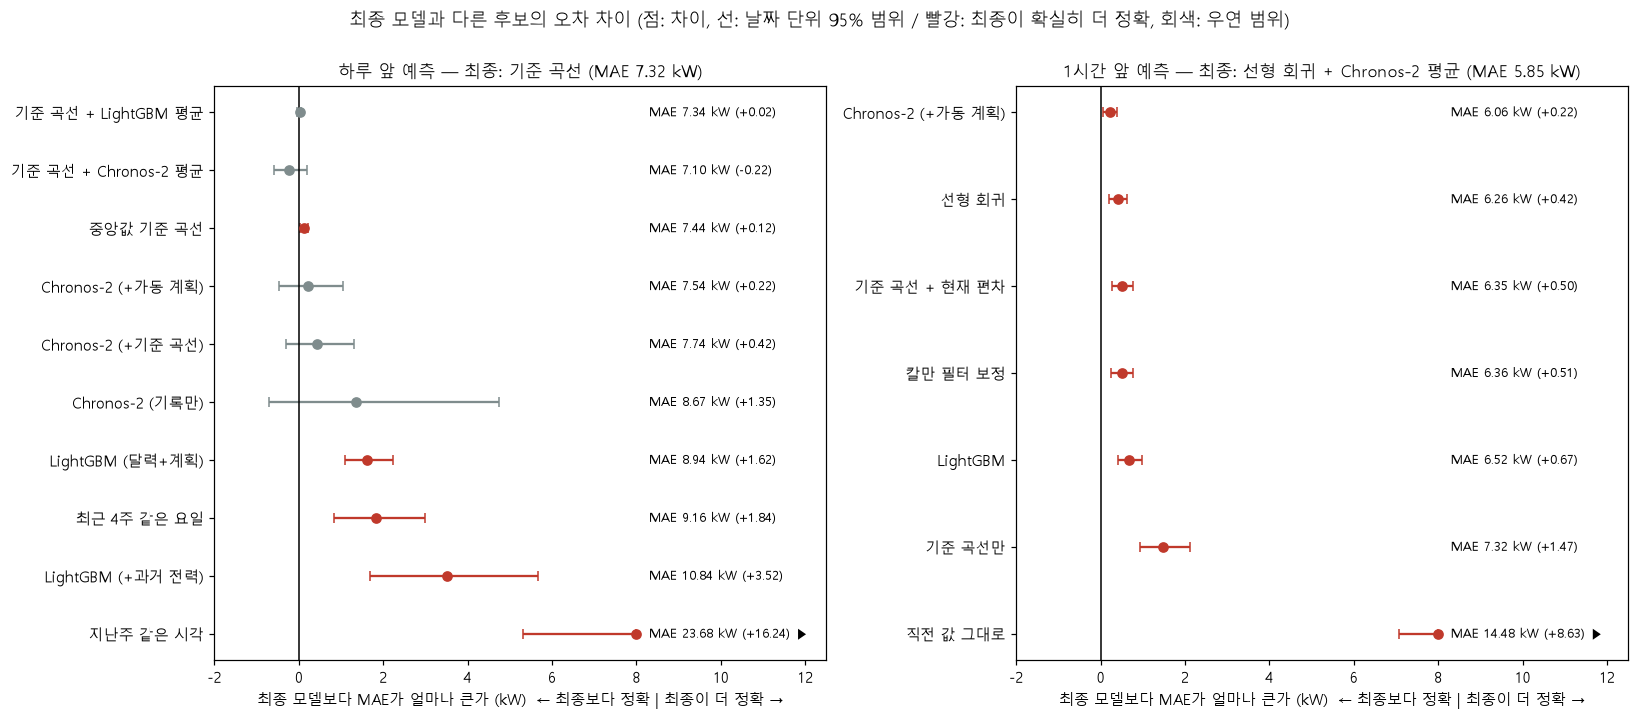

In [14]:
def mae_ci(df, model, target, n_boot=2000):
    d = df[df["정답사용"]].dropna(subset=[model])
    s = (d[model] - d[target]).abs().groupby(d["date"]).sum(); n = d.groupby("date").size()
    idx = np.random.default_rng(SEED).integers(0, len(s), (n_boot, len(s)))
    b = s.values[idx].sum(1) / n.values[idx].sum(1)
    return s.sum() / n.sum(), *np.percentile(b, [2.5, 97.5])

cand_hour["date"] = cand_hour["대상시각"].dt.normalize()
day_all = cand_day.join(day_preds[["④ LightGBM (달력+계획)", "⑤ LightGBM (+과거 전력)"]])
panels = [
    ("하루 앞 예측", day_all, "전력",
     ["기준 곡선 (최종)", "기준 곡선 + LightGBM 평균", "기준 곡선 + Chronos-2 평균", "중앙값 기준 곡선",
      "Chronos-2 (+가동 계획)", "Chronos-2 (+기준 곡선)", "Chronos-2 (기록만)", "④ LightGBM (달력+계획)",
      "② 최근 4주 같은 요일", "⑤ LightGBM (+과거 전력)", "① 지난주 같은 시각"]),
    ("1시간 앞 예측", cand_hour, "정답",
     ["선형 회귀 + Chronos-2 평균 (최종)", "Chronos-2 (+가동 계획)", "선형 회귀", "기준 곡선 + 현재 편차",
      "칼만 필터 보정", "LightGBM", "기준 곡선만", "직전 값 그대로"]),
]
def paired_diff(df, best, m, target, n_boot=2000):
    """(다른 모델 오차 − 최종 모델 오차)의 평균과 날짜 단위 부트스트랩 95% 범위. 두 모델이 모두 예측한 칸만"""
    d = df[df["정답사용"]].dropna(subset=[best, m])
    e = ((d[m] - d[target]).abs() - (d[best] - d[target]).abs()).groupby(d["date"]).sum(); n = d.groupby("date").size()
    idx = np.random.default_rng(SEED).integers(0, len(e), (n_boot, len(e)))
    b = e.values[idx].sum(1) / n.values[idx].sum(1)
    return e.sum() / n.sum(), *np.percentile(b, [2.5, 97.5])

CLIP = 8
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (title, df, tgt, models) in zip(axes, panels):
    best, others = models[0], models[1:]
    vals = [paired_diff(df, best, m, tgt) for m in others]
    maes = [mae_ci(df, m, tgt)[0] for m in others]
    ypos = np.arange(len(others))[::-1]
    for y_, (pt, lo, hi), mae_, m in zip(ypos, vals, maes, others):
        color = "#c0392b" if lo > 0 else ("#27ae60" if hi < 0 else "#7f8c8d")
        ax.errorbar(min(pt, CLIP), y_, xerr=[[min(pt, CLIP) - min(lo, CLIP)], [min(hi, CLIP) - min(pt, CLIP)]],
                    fmt="o", color=color, ecolor=color, capsize=3, lw=1.5)
        ax.text(CLIP + 0.3, y_, f"MAE {mae_:.2f} kW ({pt:+.2f})" + (" ▶" if pt > CLIP else ""), va="center", fontsize=8.5)
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(ypos); ax.set_yticklabels([m.lstrip("①②③④⑤⑥ ") for m in others], fontsize=9.5)
    ax.set_xlim(-2, CLIP + 4.5)
    ax.set_xlabel("최종 모델보다 MAE가 얼마나 큰가 (kW)  ← 최종보다 정확 | 최종이 더 정확 →")
    ax.set_title(f"{title} — 최종: {best.replace(' (최종)', '')} (MAE {mae_ci(df, best, tgt)[0]:.2f} kW)", fontsize=11)
fig.suptitle("최종 모델과 다른 후보의 오차 차이 (점: 차이, 선: 날짜 단위 95% 범위 / 빨강: 최종이 확실히 더 정확, 회색: 우연 범위)", y=1.0)
fig.tight_layout(); save_fig(fig, "f14_모델_전체비교"); plt.show()

### 3-1-1. 다른 검정으로도 같은 결론인가 — Diebold–Mariano 검정

날짜 단위 부트스트랩과 함께, 예측 비교에 널리 쓰는 Diebold–Mariano 검정도 했습니다. 날마다 '후보의 평균 절대오차 − 최종 모델의 평균 절대오차'를 구하고, 그 평균이 0과 다른지를 소표본 보정(HLN, t분포)으로 봅니다. 두 모델이 모두 예측한 칸만 씁니다.

In [15]:
# Diebold–Mariano 검정 (날짜별 평균 절대오차 차이, HLN 소표본 보정, 양측)
from scipy import stats
def dm_test(df, best, m, target):
    d = df[df["정답사용"]].dropna(subset=[best, m])
    g = ((d[m] - d[target]).abs() - (d[best] - d[target]).abs()).groupby(d["date"]).mean()
    n = len(g); dm = g.mean() / np.sqrt(g.var(ddof=1) / n)
    hln = dm * np.sqrt((n - 1) / n)                                 # h = 1
    return round(g.mean(), 2), round(hln, 2), round(2 * stats.t.sf(abs(hln), n - 1), 4), n
rows = []
for title, df, tgt, models in panels:
    best, others = models[0], models[1:]
    for m in others:
        diff, stat, p, n = dm_test(df, best, m, tgt)
        rows.append({"예측": title, "후보": m, "최종 모델": best, "날짜별 MAE 차이 평균 (kW)": diff, "DM 통계량": stat, "p값": p, "날짜 수": n,
                     "판정 (유의수준 5%)": "최종이 더 정확" if (p < 0.05 and diff > 0) else ("후보가 더 정확" if (p < 0.05 and diff < 0) else "차이 확인 안 됨")})
t_dm = pd.DataFrame(rows).set_index(["예측", "후보"])
save_table(t_dm, "t56_DM검정")
t_dm

최종 모델  날짜별 MAE 차이 평균 (kW)  \
예측       후보                                                                    
하루 앞 예측  기준 곡선 + LightGBM 평균                  기준 곡선 (최종)                0.01   
         기준 곡선 + Chronos-2 평균                 기준 곡선 (최종)               -0.10   
         중앙값 기준 곡선                            기준 곡선 (최종)                0.12   
         Chronos-2 (+가동 계획)                   기준 곡선 (최종)                0.47   
         Chronos-2 (+기준 곡선)                   기준 곡선 (최종)                0.66   
         Chronos-2 (기록만)                      기준 곡선 (최종)                1.54   
         ④ LightGBM (달력+계획)                   기준 곡선 (최종)                1.58   
         ② 최근 4주 같은 요일                        기준 곡선 (최종)                1.91   
         ⑤ LightGBM (+과거 전력)                  기준 곡선 (최종)                3.44   
         ① 지난주 같은 시각                          기준 곡선 (최종)               15.60   
1시간 앞 예측 Chronos-2 (+가동 계획)    선형 회귀 + Chronos-2 평균 (최종)                0.22   
         선형 회귀                 선형 회귀 + Chronos-2 평균 (최종)                0.40   
         기준 곡선 + 현재 편차         선형 회귀 + Chronos-2 평균 (최종)                0.48   
         칼만 필터 보정              선형 회귀 + Chronos-2 평균 (최종)                0.49   
         LightGBM              선형 회귀 + Chronos-2 평균 (최종)                0.69   
         기준 곡선만                선형 회귀 + Chronos-2 평균 (최종)                1.48   
         직전 값 그대로              선형 회귀 + Chronos-2 평균 (최종)                8.46   

                               DM 통계량      p값  날짜 수 판정 (유의수준 5%)  
예측       후보                                                       
하루 앞 예측  기준 곡선 + LightGBM 평균     0.60  0.5531    37    차이 확인 안 됨  
         기준 곡선 + Chronos-2 평균   -0.35  0.7293    37    차이 확인 안 됨  
         중앙값 기준 곡선               2.68  0.0110    37     최종이 더 정확  
         Chronos-2 (+가동 계획)      0.80  0.4307    37    차이 확인 안 됨  
         Chronos-2 (+기준 곡선)      1.10  0.2780    37    차이 확인 안 됨  
         Chronos-2 (기록만)         0.98  0.3314    37    차이 확인 안 됨  
         ④ LightGBM (달력+계획)      5.24  0.0000    37     최종이 더 정확  
         ② 최근 4주 같은 요일           3.09  0.0039    37     최종이 더 정확  
         ⑤ LightGBM (+과거 전력)     3.34  0.0020    37     최종이 더 정확  
         ① 지난주 같은 시각             2.67  0.0112    37     최종이 더 정확  
1시간 앞 예측 Chronos-2 (+가동 계획)      2.49  0.0175    37     최종이 더 정확  
         선형 회귀                   3.63  0.0009    37     최종이 더 정확  
         기준 곡선 + 현재 편차           3.31  0.0021    37     최종이 더 정확  
         칼만 필터 보정                3.37  0.0018    37     최종이 더 정확  
         LightGBM                4.05  0.0003    37     최종이 더 정확  
         기준 곡선만                  4.51  0.0001    37     최종이 더 정확  
         직전 값 그대로               10.39  0.0000    37     최종이 더 정확

**해석** — 표 56
- 17개 비교 모두 **날짜 단위 부트스트랩과 같은 결론**이었습니다.
  - 1시간 앞: 최종 모델(선형 회귀 + Chronos-2 평균)이 7개 후보 모두보다 유의하게 정확했습니다(p ≤ 0.018). 가장 가까운 Chronos-2 단독과의 차이도 p = 0.018입니다.
  - 하루 앞: 기준 곡선 + Chronos-2 평균(p = 0.73), Chronos-2 3종(p = 0.28~0.43), 기준 곡선 + LightGBM 평균(p = 0.55)은 차이가 확인되지 않았고, 나머지 5개는 기준 곡선이 유의하게 정확했습니다.
- 두 검정 모두 37개 시험일을 단위로 보므로, 같은 날의 칸끼리 닮아 있는 문제를 함께 피합니다.

### 3-2. 왜 섞으면 더 정확해지나 — 1시간 앞 예측 예시

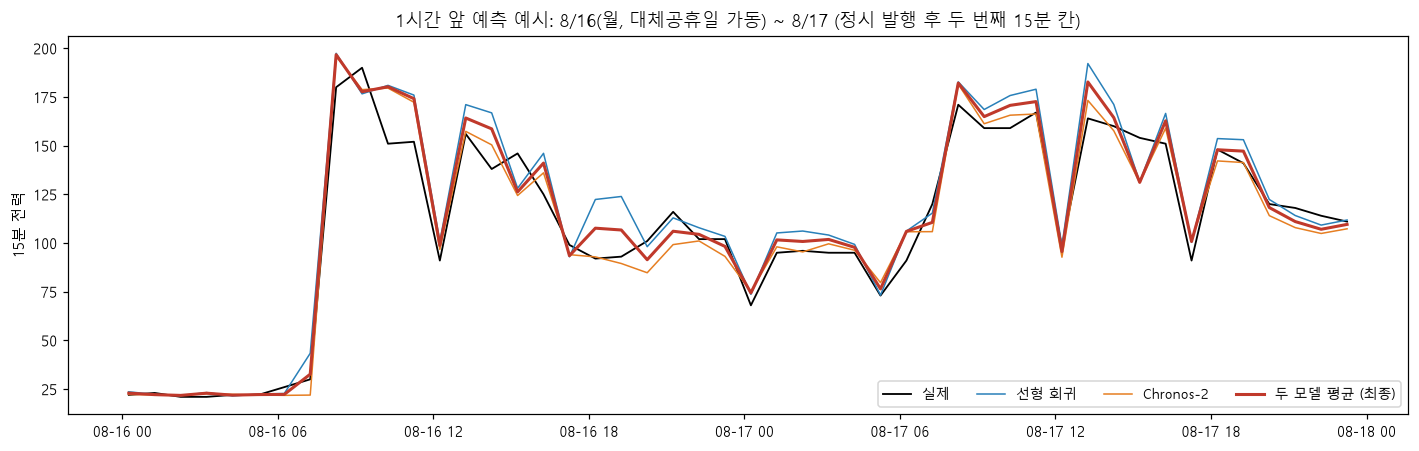

두 모델 오차의 상관계수: 0.73  (1에 가까울수록 같은 곳에서 같은 방향으로 틀림)
한 모델은 너무 높게, 다른 모델은 너무 낮게 예측한 칸의 비율: 21%


In [16]:
ex = cand_hour[(cand_hour["대상시각"] >= "2021-08-16") & (cand_hour["대상시각"] < "2021-08-18") & (cand_hour["몇번째칸"] == 2)]
ex = ex.set_index("대상시각").sort_index()
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(ex.index, ex["정답"], color="black", lw=1.2, label="실제")
ax.plot(ex.index, ex["선형 회귀"], color="#2980b9", lw=1, label="선형 회귀")
ax.plot(ex.index, ex["Chronos-2 (+가동 계획)"], color="#e67e22", lw=1, label="Chronos-2")
ax.plot(ex.index, ex["선형 회귀 + Chronos-2 평균 (최종)"], color="#c0392b", lw=2, label="두 모델 평균 (최종)")
ax.set_ylabel("15분 전력"); ax.legend(fontsize=9, ncol=4, loc="lower right")
ax.set_title("1시간 앞 예측 예시: 8/16(월, 대체공휴일 가동) ~ 8/17 (정시 발행 후 두 번째 15분 칸)")
fig.tight_layout(); save_fig(fig, "f15_1시간앞_결합예시"); plt.show()

err = cand_hour[cand_hour["정답사용"]]
e_lin = err["선형 회귀"] - err["정답"]; e_chr = err["Chronos-2 (+가동 계획)"] - err["정답"]
print(f"두 모델 오차의 상관계수: {e_lin.corr(e_chr):.2f}  (1에 가까울수록 같은 곳에서 같은 방향으로 틀림)")
print(f"한 모델은 너무 높게, 다른 모델은 너무 낮게 예측한 칸의 비율: {((e_lin * e_chr) < 0).mean():.0%}")

**해석**
- 선형 회귀는 '평소 패턴(기준 곡선) + 지금의 편차'로 예측하고, Chronos-2는 '최근 3주의 흐름 전체'를 보고 예측합니다. **보는 정보가 달라서 틀리는 방식도 다릅니다.**
- 실제로 두 모델의 오차는 같은 방향인 경우가 많지만(상관 0.73), **약 21%의 칸에서는 한쪽은 너무 높게, 다른 쪽은 너무 낮게** 예측했습니다. 이런 칸에서는 평균을 내면 오차가 서로 상쇄됩니다.
- 그림 15의 8/16 저녁(18~20시)처럼 선형 회귀가 너무 높게 잡은 구간을 Chronos-2가 낮춰 주고, 반대로 Chronos-2가 너무 낮은 구간은 선형 회귀가 올려 줍니다.

### 3-3. 결과가 우연히 좋게 나온 것은 아닌가? — 주별·날짜별 확인
최종 모델은 여러 후보를 **같은 시험 기간의 결과로 비교해서** 골랐습니다. 이렇게 고르면 그 기간에 우연히 잘 맞은 모델이 뽑힐 수 있어, 성능이 실제보다 조금 좋게 보일 수 있습니다(선택 편향).
그래서 두 가지를 확인합니다.
1. **주마다, 날마다 일관되게 이기는가**
2. **섞는 비율을 바꿔도 결과가 비슷한가** (반반 비율을 시험 결과에 맞춰 고른 것이 아니라는 확인)

In [17]:
ok = cand_hour[cand_hour["정답사용"]].copy()
FIN, LIN, CHR = "선형 회귀 + Chronos-2 평균 (최종)", "선형 회귀", "Chronos-2 (+가동 계획)"
for m in [FIN, LIN, CHR]:
    ok["오차_" + m] = (ok[m] - ok["정답"]).abs()
weekly_cmp = ok.groupby("시험주")[["오차_" + m for m in [FIN, LIN, CHR]]].mean()
weekly_cmp.columns = ["최종 (평균 결합)", "선형 회귀", "Chronos-2"]
weekly_cmp["최종이 선형 회귀보다 나은가"] = np.where(weekly_cmp["최종 (평균 결합)"] < weekly_cmp["선형 회귀"], "예", "아니오")
save_table(weekly_cmp.round(2), "t17_1시간앞_주별비교")
daily = ok.groupby("date")[["오차_" + FIN, "오차_" + LIN]].mean()
print(f"37일 중 최종 모델이 선형 회귀보다 나은 날: {(daily['오차_' + FIN] < daily['오차_' + LIN]).sum()}일")

mix = pd.Series({w: ((w * ok[LIN] + (1 - w) * ok[CHR]) - ok["정답"]).abs().mean() for w in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]})
mix.index = [f"선형 회귀 {round(w*100)}% : Chronos-2 {round((1-w)*100)}%" for w in mix.index]
print()
print("섞는 비율에 따른 MAE:"); print(mix.round(2).to_string())

# 표본 밖 점검: 섞는 비율을 '그 주 이전의 시험 주'만 보고 고르면? (1주차는 반반, 2주차부터 앞선 주로 학습)
weeks = sorted(ok["시험주"].unique())
w_sel = {weeks[0]: 0.5}
for k in range(1, len(weeks)):
    past = ok[ok["시험주"].isin(weeks[:k])]
    w_sel[weeks[k]] = min(np.arange(0, 1.001, 0.05), key=lambda w: ((w * past[LIN] + (1 - w) * past[CHR]) - past["정답"]).abs().mean())
w_week = ok["시험주"].map(w_sel)
mae_learned = ((w_week * ok[LIN] + (1 - w_week) * ok[CHR]) - ok["정답"]).abs().mean()
print()
print("앞선 주로 고른 선형 회귀 비율:", {k: round(v, 2) for k, v in w_sel.items()})
print(f"→ 비율을 데이터로 학습해 쓴 경우 MAE {mae_learned:.2f} / 반반 고정(최종) {ok['오차_' + FIN].mean():.2f}")
weekly_cmp.round(2)

37일 중 최종 모델이 선형 회귀보다 나은 날: 29일

섞는 비율에 따른 MAE:
선형 회귀 0% : Chronos-2 100%    6.06
선형 회귀 20% : Chronos-2 80%    5.90
선형 회귀 40% : Chronos-2 60%    5.84
선형 회귀 50% : Chronos-2 50%    5.85
선형 회귀 60% : Chronos-2 40%    5.88
선형 회귀 80% : Chronos-2 20%    6.02
선형 회귀 100% : Chronos-2 0%    6.26

앞선 주로 고른 선형 회귀 비율: {'08/09': 0.5, '08/16': np.float64(0.85), '08/23': np.float64(0.4), '08/30': np.float64(0.45), '09/06': np.float64(0.4)}
→ 비율을 데이터로 학습해 쓴 경우 MAE 5.95 / 반반 고정(최종) 5.85


,최종 (평균 결합),선형 회귀,Chronos-2,최종이 선형 회귀보다 나은가
시험주,,,,
08/09,6.37,6.29,6.88,아니오
08/16,6.08,6.95,6.01,예
08/23,5.78,6.12,6.15,예
08/30,5.50,6.01,5.57,예
09/06,5.59,6.00,5.79,예


**해석**
- 최종 모델은 **5주 중 4주**, **37일 중 29일**에서 선형 회귀보다 정확했습니다. 지지 않은 한 주(1주차, 하계 휴무 직후)도 차이가 작습니다(6.37 vs 6.29).
- 섞는 비율을 40~60% 사이에서 바꿔도 오차는 5.84~5.88로 거의 같습니다. 반반 비율은 시험 결과에 맞춰 고른 값이 아니고, 그 근처 어디를 골라도 결과가 비슷합니다.
- 반대로 **비율을 데이터로 학습해서 쓰면 오히려 나빠집니다.** 매주 '그 주 이전의 시험 주'만 보고 비율을 고르면 2주차에 선형 회귀 쪽으로 크게 쏠렸다가(85%) 손해를 보아, 5주 전체 MAE가 5.95로 반반 고정(5.85)보다 큽니다. 자료가 적을 때는 가중치를 맞추기보다 단순 평균이 안전하다는 예측 결합 연구의 결론과 같습니다. 반반 고정은 시험 결과를 보고 고른 값이 아니라, 처음부터 정한 가장 단순한 규칙입니다.
- 다만 여러 후보 중 시험 결과가 가장 좋은 것을 골랐으므로, **실제 운영 성능은 5.85보다 조금 나쁠 수 있습니다.** 보고서에 이 점을 함께 밝힙니다.

### 3-4. 1~6월 기록을 함께 쓰면 어떻게 되나?
01-1 노트북에서 1~6월의 62%가 다른 날과 전력 기록이 똑같은 날이라는 것을 확인하고, 7/1 이후만 썼습니다. 이 결정이 결과에 얼마나 영향을 주는지 숫자로 확인합니다.
같은 두 모델(기준 곡선, 같은 정보를 쓰는 LightGBM)을 세 가지 방식으로 학습·평가합니다.
1. **1~9월 전체 + 날짜를 무작위로 나눔**: 가이드북 베이스라인처럼 날짜를 섞어 80%로 학습, 20%로 평가 (20번 반복 평균)
2. **1~9월 전체 + 시간순**: 8/8까지 학습, 8/9~9/14 평가
3. **우리 방식: 7/1 이후 + 시간순**: 7/1~8/8 학습, 8/9~9/14 평가 (한 번에 나눈 경우. 본문의 7.32는 매주 학습 기간을 늘린 결과)

In [18]:
# 1~9월 전체를 15분 칸으로 펼침 (01-2 노트북과 같은 방식: 행 순서로 시각, 7/13·7/15와 0은 빈 값)
raw = pd.read_csv("../data/raw/okm_augumented_2021.csv", encoding="utf-8-sig")
raw["date"] = pd.to_datetime(raw["날짜"].astype(str), format="%Y%m%d")
raw["hour"] = raw.groupby("date").cumcount()
Q = {"15분": 0, "30분": 1, "45분": 2, "60분": 3}
full = raw.melt(id_vars=["date", "hour"], value_vars=list(Q), var_name="칸", value_name="전력")
full["칸번호"] = full["hour"] * 4 + full["칸"].map(Q)
full["전력"] = full["전력"].astype(float).replace(0, np.nan)
BROKEN = pd.to_datetime(["2021-07-13", "2021-07-15"])
full.loc[full["date"].isin(BROKEN), "전력"] = np.nan
dinfo = raw.groupby("date").agg(일생산량=("생산량", "sum"))
dinfo["가동일"] = dinfo["일생산량"] > 0
dinfo.loc[BROKEN, "가동일"] = True
dinfo["하루종류코드"] = np.select([~dinfo["가동일"], dinfo.index.dayofweek == 5], [2, 1], 0)
dinfo["전날가동"] = dinfo["가동일"].shift(1, fill_value=True)
full = full.join(dinfo[["하루종류코드", "전날가동"]], on="date").dropna(subset=["전력"])

# 다른 날과 96칸 전력이 똑같은 날 표시
wide = full.pivot(index="date", columns="칸번호", values="전력")
sig = wide.fillna(-1).astype(int).astype(str).agg("|".join, axis=1)
twin = sig.map(sig.value_counts()) > 1

def fit_eval(train, test):
    """기준 곡선과 LightGBM(같은 정보)을 학습해 시험 MAE를 돌려줌"""
    curve = train.groupby(KEY_F)["전력"].mean().rename("c")
    pc = test.join(curve, on=KEY_F)["c"]
    pl = lgbm(colsample_bytree=1.0).fit(train[KEY_F].astype(float), train["전력"]).predict(test[KEY_F].astype(float))
    ok_ = pc.notna()
    return (pc - test["전력"]).abs()[ok_].mean(), np.abs(pl - test["전력"].values)[ok_.values].mean()

days_all = wide.index[wide.index < "2021-09-15"]
rng = np.random.default_rng(SEED)
r1, share = [], []
for _ in range(20):
    te_days = rng.choice(days_all, size=int(len(days_all) * 0.2), replace=False)
    tr, te = full[~full["date"].isin(te_days)], full[full["date"].isin(te_days)]
    r1.append(fit_eval(tr, te))
    tr_sig = set(sig[sig.index.isin(tr["date"].unique())])
    share.append(np.mean([sig[d] in tr_sig for d in te_days]))
TEST_FROM, TEST_TO = pd.Timestamp("2021-08-09"), pd.Timestamp("2021-09-15")
EXCL = pd.to_datetime(["2021-07-28", "2021-07-30"])
te_time = full[(full["date"] >= TEST_FROM) & (full["date"] < TEST_TO)]
r2 = fit_eval(full[full["date"] < TEST_FROM], te_time)
r3 = fit_eval(full[(full["date"] >= "2021-07-01") & (full["date"] < TEST_FROM) & ~full["date"].isin(EXCL)], te_time)

inflate = pd.DataFrame({
    "기준 곡선 MAE": [np.mean([a for a, _ in r1]), r2[0], r3[0]],
    "LightGBM MAE": [np.mean([b for _, b in r1]), r2[1], r3[1]],
    "시험일 중 학습에 똑같은 날이 있는 비율": [f"{np.mean(share):.0%}", "0%", "0%"],
}, index=["① 1~9월 전체 + 날짜 무작위 분할", "② 1~9월 전체 + 시간순 (8/9~9/14 평가)", "③ 7/1 이후만 + 시간순 (8/9~9/14 평가, 우리 방식)"]).round(2)
save_table(inflate, "t33_데이터_사용방식별_성능")
print(f"다른 날과 전력이 똑같은 날: {twin.sum()}일 / {len(twin)}일")
inflate

다른 날과 전력이 똑같은 날: 160일 / 255일


,기준 곡선 MAE,LightGBM MAE,시험일 중 학습에 똑같은 날이 있는 비율
① 1~9월 전체 + 날짜 무작위 분할,16.98,17.13,61%
② 1~9월 전체 + 시간순 (8/9~9/14 평가),13.52,13.56,0%
"③ 7/1 이후만 + 시간순 (8/9~9/14 평가, 우리 방식)",7.60,7.78,0%


**해석**
- **같은 시험 기간(8/9~9/14)으로 비교하면, 1~6월 기록을 섞을 때 오차가 7.60에서 13.52로 약 1.8배 커집니다(② vs ③).** 두 모델 모두 같습니다.
  복사된 날은 전력 곡선은 다른 날과 똑같은데 생산 기록은 달라서, '가동하는 날 + 시각 → 전력'이라는 관계를 흐립니다. 7/1 이후만 쓰기로 한 결정이 성능에 직접 도움이 되었다는 뜻입니다.
- 날짜를 무작위로 나누면(①) **시험일의 61%가 학습 데이터 안에 전력이 똑같은 날을 가지고 있습니다.** 어제·지난주 전력처럼 과거 기록을 입력으로 쓰는 모델은 이 경우 답을 미리 본 셈이 되어 성능이 실제보다 좋게 나올 위험이 큽니다.
  우리 두 모델은 과거 전력을 쓰지 않아 ①의 점수가 낮아지지는 않았습니다. 대신 1~6월의 맞지 않는 기록 때문에 오차가 가장 큽니다. ①은 시험일이 달라 ②·③과 직접 비교하지는 않습니다.
- 정리하면, 1~6월 기록은 **섞으면 모델을 망치고, 무작위로 나누면 평가를 믿을 수 없게 만듭니다.** 그래서 이 분석은 7/1 이후의 실제 측정 기록만, 시간 순서대로 나누어 평가합니다.

### 3-5. 하루 앞 최종 모델을 고르는 근거 확인
두 예측 모두 **같은 규칙**으로 최종 모델을 고릅니다.
- **규칙**: 더 복잡한 후보는 '기준 곡선(하루 앞)·선형 회귀(1시간 앞)보다 전체 MAE가 낮고, 그 차이가 날짜를 다시 뽑아도 유지될 때(95% 범위가 0을 넘지 않을 때)'만 채택합니다. 차이가 우연 범위면 더 단순한 쪽을 씁니다.
- 고부하 구간 MAE는 평균으로의 회귀 때문에 해석이 어려워(02-3 노트북) 선택 기준으로 쓰지 않습니다.

하루 앞에서 MAE가 가장 낮았던 '기준 곡선 + Chronos-2 평균'을 이 규칙으로 다시 봅니다.

In [19]:
A, B = "기준 곡선 (최종)", "기준 곡선 + Chronos-2 평균"
okd = cand_day[cand_day["정답사용"]]
wk = okd.groupby("시험주").apply(lambda g: pd.Series({m: (g[m] - g["전력"]).abs().mean() for m in [A, B]})).round(2)
wk["더 정확한 쪽"] = np.where(wk[B] < wk[A], "평균 결합", "기준 곡선")
dmax = {m: (okd.groupby("date")[m].max() - okd.groupby("date")["전력"].max()).abs().mean() for m in [A, B]}
print(compare(cand_day, A, [B]).to_string())
print(f"하루 최대 전력 오차 — 기준 곡선 {dmax[A]:.2f}, 평균 결합 {dmax[B]:.2f}")
wk

                     MAE 차이 (다른 모델 − 기준)        95% 범위             판정
기준 곡선 + Chronos-2 평균               -0.22  -0.59 ~ 0.20  우연 범위 (차이 없음)
하루 최대 전력 오차 — 기준 곡선 7.23, 평균 결합 7.36


,기준 곡선 (최종),기준 곡선 + Chronos-2 평균,더 정확한 쪽
시험주,,,
08/09,6.69,6.51,평균 결합
08/16,9.14,8.28,평균 결합
08/23,7.28,8.07,기준 곡선
08/30,6.83,6.32,평균 결합
09/06,6.80,6.55,평균 결합


**해석**
- '기준 곡선 + Chronos-2 평균'은 5주 평균 MAE가 0.22 낮지만, **날짜를 다시 뽑으면 차이의 95% 범위(−0.59 ~ 0.20)가 0을 포함**합니다. 우연 범위입니다.
- 5주 중 **8/23 주는 오히려 더 나쁘고**(7.28 → 8.07), 하루 최대 전력의 오차도 기준 곡선이 조금 작습니다(7.23 vs 7.36).
- 그래서 규칙에 따라 **더 단순하고 설명하기 쉬운 기준 곡선**을 하루 앞 최종 모델로 둡니다. 1시간 앞의 '선형 회귀 + Chronos-2 평균'은 같은 규칙에서 확실히 더 정확했기 때문에(2-6, 3-3) 채택했습니다.

### 3-6. 다른 모델 계열과의 비교 — 딥러닝·통계 모델, 다른 공장 자료로 미세조정한 Chronos-2
02-1b 노트북(딥러닝·통계)과 02-1c 노트북(미세조정)에서 같은 5주·같은 발행 시각으로 만든 예측을 불러와, 최종 모델과 같은 방법(날짜 단위 부트스트랩, Diebold–Mariano 검정)으로 비교합니다.
- 새 후보를 최종 모델과 섞었을 때 나아지는지도 봅니다. 3절에서 Chronos-2를 섞어 본 것과 같은 방식으로, 하루 앞은 **기준 곡선 + (새 후보) 평균**, 1시간 앞은 **선형 회귀 + (새 후보) 평균**을 만들어 같은 검정을 합니다.

In [20]:
NEW_DAY = ["MSTL", "ARIMA (+달력·가동 계획)", "ARIMA (+기준 곡선)", "NHITS", "TFT"]
NEW_HOUR = ["ARIMA (+달력·가동 계획)", "ARIMA (+기준 곡선)", "NHITS", "TFT", "Chronos-2 미세조정 (다른 공장 자료)"]
for p in ["extra_day_ahead.csv", "extra_hour_ahead.csv", "chronos_ft_hour_ahead.csv"]:
    assert (PRED_DIR / p).exists(), f"{p}가 없습니다. 02-1b·02-1c 노트북을 먼저 실행하세요."
ex_day = pd.read_csv(PRED_DIR / "extra_day_ahead.csv", encoding="utf-8-sig", parse_dates=["ts"]).pivot(index="ts", columns="모델", values="예측")
ex_hour = pd.read_csv(PRED_DIR / "extra_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"]).pivot_table(
    index=["발행시각", "대상시각"], columns="모델", values="예측").reset_index()
ft = pd.read_csv(PRED_DIR / "chronos_ft_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
ex_hour = ex_hour.merge(ft[["발행시각", "대상시각", "예측"]].rename(columns={"예측": NEW_HOUR[-1]}), on=["발행시각", "대상시각"])

day_ext = day_all.join(ex_day[NEW_DAY])
hour_ext = cand_hour.merge(ex_hour, on=["발행시각", "대상시각"], how="left")
assert day_ext[NEW_DAY].notna().all().all() and hour_ext[NEW_HOUR].notna().all().all()
FIN_D, FIN_H = "기준 곡선 (최종)", "선형 회귀 + Chronos-2 평균 (최종)"
# 3절과 같은 반반 평균: 하루 앞은 기준 곡선과, 1시간 앞은 선형 회귀와 섞음
MIX_DAY = {m: f"기준 곡선 + {m} 평균" for m in NEW_DAY}
for m, name in MIX_DAY.items():
    day_ext[name] = (day_ext[FIN_D] + day_ext[m]) / 2
MIX = {m: f"선형 회귀 + {m} 평균" for m in NEW_HOUR}
for m, name in MIX.items():
    hour_ext[name] = (hour_ext["선형 회귀"] + hour_ext[m]) / 2
NEW_DAY_ALL = NEW_DAY + list(MIX_DAY.values())
NEW_HOUR_ALL = NEW_HOUR + list(MIX.values())

def compare_table(df, best, others, target, daymax):
    t = evaluate(df, [best] + others, target=target, daymax=daymax).drop(columns="평가 칸 수")
    t = t.join(compare(df, best, others, target=target).rename(columns={"MAE 차이 (다른 모델 − 기준)": "최종 모델과 MAE 차이"}))
    t["DM p값"] = [np.nan] + [dm_test(df, best, m, target)[2] for m in others]
    return t
t_new = pd.concat({"하루 앞": compare_table(day_ext, FIN_D, NEW_DAY_ALL, "전력", True),
                   "1시간 앞": compare_table(hour_ext, FIN_H, NEW_HOUR_ALL, "정답", False)})
save_table(t_new, "t57_다른모델계열_비교")
t_new

MAE   RMSE  상대오차(%)  고부하 구간 MAE  \
하루 앞  기준 곡선 (최종)                             7.32  10.98     7.03        7.99   
      MSTL                                  11.64  17.18    11.17       24.98   
      ARIMA (+달력·가동 계획)                     18.11  23.70    17.38       21.45   
      ARIMA (+기준 곡선)                         7.71  11.36     7.40        8.67   
      NHITS                                 13.96  22.85    13.40       32.39   
      TFT                                   12.18  19.65    11.70        9.59   
      기준 곡선 + MSTL 평균                        8.44  12.13     8.11       15.87   
      기준 곡선 + ARIMA (+달력·가동 계획) 평균          11.20  14.51    10.76       13.70   
      기준 곡선 + ARIMA (+기준 곡선) 평균              7.21  10.88     6.92        8.19   
      기준 곡선 + NHITS 평균                       9.54  14.63     9.16       19.49   
      기준 곡선 + TFT 평균                         9.09  13.57     8.73        8.38   
1시간 앞 선형 회귀 + Chronos-2 평균 (최종)              5.85   8.53     5.61        8.40   
      ARIMA (+달력·가동 계획)                     13.25  19.35    12.72       20.35   
      ARIMA (+기준 곡선)                         6.07   8.93     5.82        7.86   
      NHITS                                  9.59  14.58     9.21       17.90   
      TFT                                   11.75  19.25    11.28        9.85   
      Chronos-2 미세조정 (다른 공장 자료)              6.10   9.27     5.86        9.86   
      선형 회귀 + ARIMA (+달력·가동 계획) 평균           8.39  11.79     8.05       13.03   
      선형 회귀 + ARIMA (+기준 곡선) 평균              6.05   8.88     5.81        7.99   
      선형 회귀 + NHITS 평균                       7.23  10.46     6.94       12.55   
      선형 회귀 + TFT 평균                         8.15  12.20     7.82        8.43   
      선형 회귀 + Chronos-2 미세조정 (다른 공장 자료) 평균   5.85   8.52     5.62        8.64   

                                            하루 최대 전력 오차    주별 MAE 범위  \
하루 앞  기준 곡선 (최종)                                   7.23    6.7 ~ 9.1   
      MSTL                                        17.80   8.5 ~ 21.2   
      ARIMA (+달력·가동 계획)                           18.28  16.4 ~ 19.7   
      ARIMA (+기준 곡선)                               8.00    6.7 ~ 8.6   
      NHITS                                       16.58   8.5 ~ 27.7   
      TFT                                          7.75  11.2 ~ 13.3   
      기준 곡선 + MSTL 평균                             11.71   6.6 ~ 12.4   
      기준 곡선 + ARIMA (+달력·가동 계획) 평균                12.56  10.4 ~ 12.3   
      기준 곡선 + ARIMA (+기준 곡선) 평균                    7.40    6.5 ~ 8.0   
      기준 곡선 + NHITS 평균                            12.04   6.9 ~ 15.1   
      기준 곡선 + TFT 평균                               7.57   8.3 ~ 10.8   
1시간 앞 선형 회귀 + Chronos-2 평균 (최종)                     NaN    5.5 ~ 6.4   
      ARIMA (+달력·가동 계획)                             NaN  12.0 ~ 14.7   
      ARIMA (+기준 곡선)                                NaN    5.8 ~ 6.2   
      NHITS                                         NaN   8.2 ~ 14.3   
      TFT                                           NaN  11.1 ~ 13.4   
      Chronos-2 미세조정 (다른 공장 자료)                     NaN    5.7 ~ 6.9   
      선형 회귀 + ARIMA (+달력·가동 계획) 평균                  NaN    7.8 ~ 9.4   
      선형 회귀 + ARIMA (+기준 곡선) 평균                     NaN    5.8 ~ 6.3   
      선형 회귀 + NHITS 평균                              NaN    6.5 ~ 9.0   
      선형 회귀 + TFT 평균                                NaN    7.7 ~ 9.5   
      선형 회귀 + Chronos-2 미세조정 (다른 공장 자료) 평균          NaN    5.5 ~ 6.4   

                                           최종 모델과 MAE 차이        95% 범위  \
하루 앞  기준 곡선 (최종)                                     NaN           NaN   
      MSTL                                          4.32   2.26 ~ 6.87   
      ARIMA (+달력·가동 계획)                            10.79  8.40 ~ 13.25   
      ARIMA (+기준 곡선)                                0.39  -0.10 ~ 0.92   
      NHITS                                         6.64  3.51 ~ 10.77   
      TFT                                           4.86   3.97 ~ 5.74   
      기

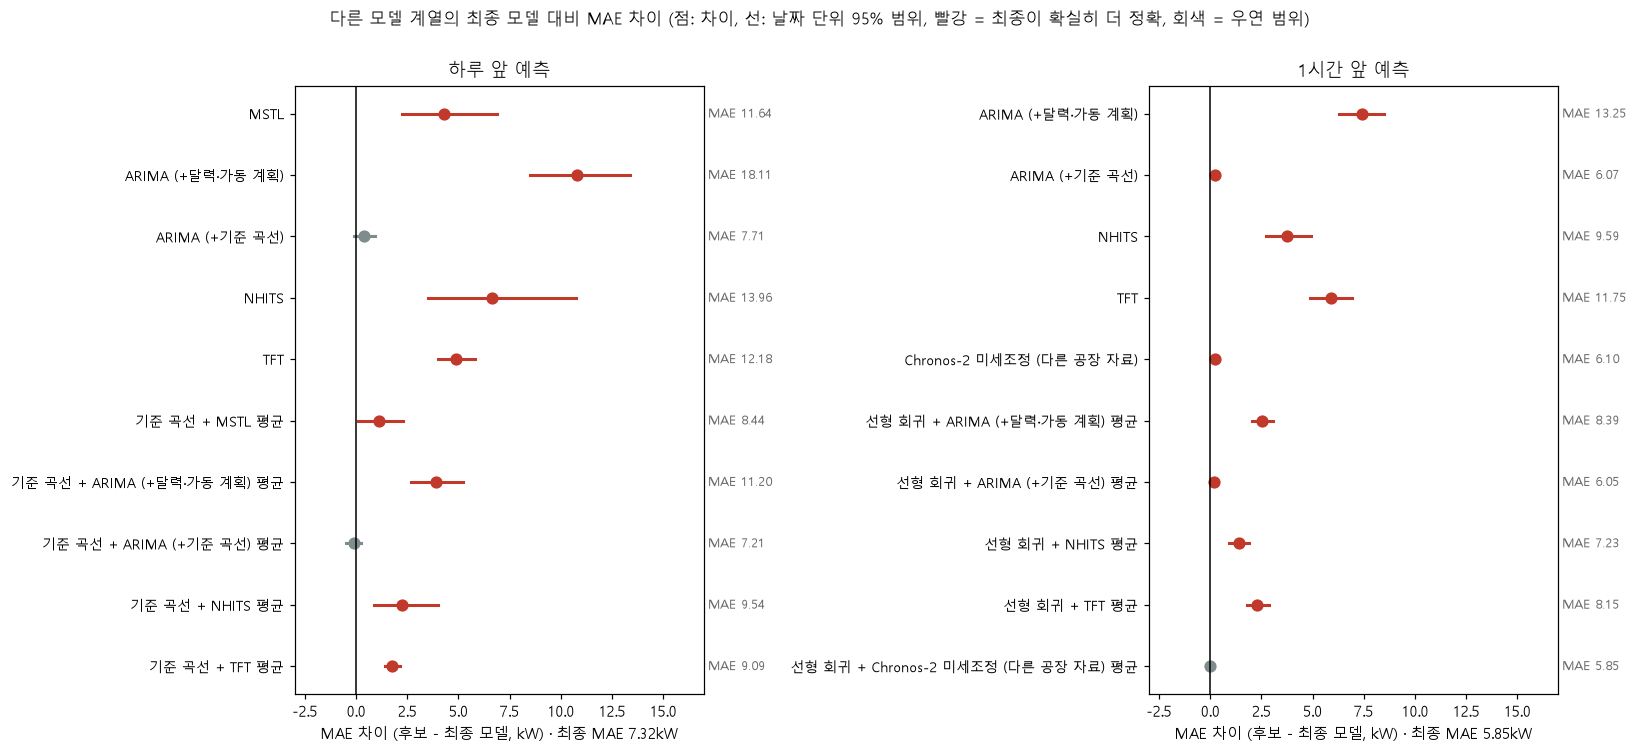

In [21]:
# 그림 32: 새 후보의 최종 모델 대비 MAE 차이와 95% 범위 (그림 14와 같은 방식)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))
for ax, (title, df, tgt, best, models) in zip(axes, [("하루 앞 예측", day_ext, "전력", FIN_D, NEW_DAY_ALL),
                                                     ("1시간 앞 예측", hour_ext, "정답", FIN_H, NEW_HOUR_ALL)]):
    vals = [paired_diff(df, best, m, tgt) for m in models]
    ypos = np.arange(len(models))[::-1]
    for y_, (pt, lo, hi), m in zip(ypos, vals, models):
        c = "#c0392b" if lo > 0 else ("#2471a3" if hi < 0 else "#7f8c8d")
        ax.plot([max(lo, -CLIP), min(hi, CLIP * 2)], [y_, y_], color=c, lw=2)
        ax.plot(min(pt, CLIP * 2), y_, "o", color=c, ms=7)
        ax.text(1.01, y_, f"MAE {mae_ci(df, m, tgt)[0]:.2f}", transform=ax.get_yaxis_transform(), va="center", fontsize=8.5, color="dimgray")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(ypos); ax.set_yticklabels(models, fontsize=9)
    ax.set_xlim(-3, CLIP * 2 + 1); ax.set_xlabel(f"MAE 차이 (후보 - 최종 모델, kW) · 최종 MAE {mae_ci(df, best, tgt)[0]:.2f}kW")
    ax.set_title(title)
fig.suptitle("다른 모델 계열의 최종 모델 대비 MAE 차이 (점: 차이, 선: 날짜 단위 95% 범위, 빨강 = 최종이 확실히 더 정확, 회색 = 우연 범위)", y=1.0, fontsize=11)
fig.tight_layout(); save_fig(fig, "f32_다른모델계열_비교"); plt.show()

**해석** — 표 57, 그림 32
- **하루 앞**: 기준 곡선(7.32)보다 확실히 정확한 후보는 없었습니다.
  - 단독 모델 중에서는 기준 곡선을 입력으로 쓴 ARIMA(7.71)만 차이가 우연 범위였습니다. 과거 기록만 보는 MSTL(11.64)과 가동 계획을 받는 NHITS(13.96)·TFT(12.18)는 유의하게 나빴고, 부록 파이프라인 구성의 ARIMA(+달력·가동 계획)는 18.11이었습니다.
  - 새로 넣은 '기준 곡선 + 후보 평균' 중 가장 좋은 '기준 곡선 + ARIMA(+기준 곡선) 평균'은 7.21로 평균 0.11 낮지만, 95% 범위(−0.50 ~ 0.23)가 0을 포함하고 DM p = 0.68이라 우연 범위입니다. 고부하 구간 MAE는 7.99에서 8.19로 오히려 커집니다. 3-5의 규칙대로 기준 곡선을 그대로 둡니다.
  - 기준 곡선에 가까웠던 후보는 모두 기준 곡선(하루 종류 × 시각 구조)을 입력으로 쓰거나 기준 곡선과 섞은 경우였습니다.
- **1시간 앞**: 최종 모델(5.85)보다 정확한 후보는 없었습니다.
  - 다른 공장 자료로 미세조정한 Chronos-2는 6.10으로 미세조정 전(6.06, 표 16)보다 나아지지 않았고, 선형 회귀와 섞어도 5.85로 최종 모델과 같았습니다(차이 0.00). **CPU 제약으로 짧게 학습한 설정(02-1c 2절)에서는 개선이 없었다**는 뜻이며, 더 길게 학습한 경우는 확인하지 못했습니다.
  - **피크 구간에서는 오히려 나빴습니다.** 고부하 구간 MAE가 미세조정 단독 9.86(미세조정 전 9.37, 표 16), 선형 회귀와 섞은 경우 8.64(최종 8.40)입니다.
- **NHITS·TFT는 CPU 시간 때문에 줄인 설정의 결과입니다**(02-1b). 1시간 앞에서 두 모델의 오차(9.59·11.75)는 직전 전력을 쓰지 않는 기준 곡선만 쓸 때(7.32, 표 11)보다도 커서, 학습이 충분하지 않았을 가능성이 큽니다. 이 비교는 줄인 설정에서의 결과이며 딥러닝 계열 전체에 대한 결론은 아닙니다.
- **두 검정의 결론**: 20개 비교 중 19개에서 날짜 단위 부트스트랩과 DM 검정의 결론이 같았습니다. '기준 곡선 + MSTL 평균'만 부트스트랩으로는 최종 모델이 더 정확했고(0.11 ~ 2.25) DM 검정으로는 차이가 확인되지 않았습니다(p = 0.055). 또 후보가 20개라 유의수준 5%에서도 우연히 '차이 있음'이 나올 수 있으므로, p값이 0.05 근처인 결과(1시간 앞 ARIMA(+기준 곡선) p = 0.032, 선형 회귀 + ARIMA(+기준 곡선) 평균 p = 0.049)는 확정적인 차이로 보지 않습니다.

### 3-7. 선택 편향 점검 — 앞 주 결과만 보고 매주 다시 고르면
최종 모델은 5주 전체 결과를 보고 골랐습니다(3-3). 그래서 최종 모델의 성능에는 선택 편향이 들어 있고, 같은 5주(또는 그 일부)에서 순위를 다시 보는 것으로는 이 편향을 확인할 수 없습니다.

그래서 3-3에서 섞는 비율을 점검한 것처럼, **매주 그 주 이전의 시험 주 결과만 보고 모델을 고른 뒤 그 주로 평가**합니다. 고를 때 쓰지 않은 주로만 평가하므로, 이렇게 얻은 2~5주차 MAE는 '선택 방법을 미리 정해 두고 운영했을 때'의 성능을 선택 편향 없이 보여 줍니다.

| 고르는 방법 | 내용 |
|---|---|
| 앞 주로 매주 다시 고름 (3-5 규칙) | 최종 모델을 고른 규칙 그대로. 기준 모델(하루 앞: 기준 곡선, 1시간 앞: 선형 회귀)보다 MAE가 낮고 그 차이의 95% 범위(앞 주들의 날짜 단위 부트스트랩)가 0을 넘지 않는 후보 중 MAE가 가장 낮은 것. 없으면 기준 모델 |
| 앞 주로 매주 다시 고름 (MAE 최소) | 앞 주들에서 MAE가 가장 낮은 후보 |
| 1주차만 보고 한 번 고름 (MAE 최소) | 경보 여유값처럼 1주차로 한 번 정하고 2~5주차에 그대로 씀 |

- 2주차는 1주차만, 5주차는 1~4주차를 보고 고릅니다. 후보는 3-1·3-6에서 비교한 모든 모델입니다(모든 후보가 예측한 칸만 사용).
- **기준 모델과 MAE 차이**는 고르는 과정 자체가 표본 밖에서도 이득인지(고르지 않고 기준 모델만 쓸 때와 비교), **최종 모델과 MAE 차이**는 5주 결과로 고른 최종 모델의 성능이 얼마나 낙관적인지를 보여 줍니다. 하루 앞은 기준 모델이 곧 최종 모델이라 앞의 열은 비워 둡니다.
- 표의 마지막 줄(5주 결과로 고른 최종 모델의 2~5주차 MAE)은 선택 편향이 들어 있는 참고값입니다.

In [22]:
def reselect_weekly(df, models, base, final, target):
    """매주 그 주 이전의 시험 주 결과만 보고 모델을 고르고, 그 주로 평가 (2~5주차)"""
    d = df[df["정답사용"]].dropna(subset=models).copy()
    weeks = sorted(d["시험주"].unique())
    picks = {"앞 주로 매주 다시 고름 (3-5 규칙)": {}, "앞 주로 매주 다시 고름 (MAE 최소)": {}, "1주차만 보고 한 번 고름 (MAE 최소)": {}}
    for k in range(1, len(weeks)):
        past = d[d["시험주"].isin(weeks[:k])]
        mae = pd.Series({m: (past[m] - past[target]).abs().mean() for m in models})
        better = [m for m in models if m != base and mae[m] < mae[base] and paired_diff(past, base, m, target)[2] < 0]
        picks["앞 주로 매주 다시 고름 (3-5 규칙)"][weeks[k]] = min(better, key=mae.get) if better else base
        picks["앞 주로 매주 다시 고름 (MAE 최소)"][weeks[k]] = mae.idxmin()
        picks["1주차만 보고 한 번 고름 (MAE 최소)"][weeks[k]] = picks["앞 주로 매주 다시 고름 (MAE 최소)"][weeks[1]]
    rest = d[d["시험주"].isin(weeks[1:])].copy()
    def diff_text(ref, m):
        r = compare(rest, ref, [m], target=target).iloc[0]
        return f"{r.iloc[0]:+.2f} ({r.iloc[1]})"
    rows = {}
    for name, pick in picks.items():
        rest[name] = np.select([rest["시험주"] == w for w in pick], [rest[m] for m in pick.values()], np.nan)
        rows[name] = {"고른 모델 (2·3·4·5주차)": " / ".join(pick.values()), "2~5주차 MAE": round(mae_ci(rest, name, target)[0], 2),
                      "기준 모델과 MAE 차이 (95% 범위)": diff_text(base, name) if base != final else "–",
                      "최종 모델과 MAE 차이 (95% 범위)": diff_text(final, name)}
    if base != final:
        rows["(참고) 고르지 않고 기준 모델만 씀"] = {"고른 모델 (2·3·4·5주차)": base, "2~5주차 MAE": round(mae_ci(rest, base, target)[0], 2),
                                         "기준 모델과 MAE 차이 (95% 범위)": "–", "최종 모델과 MAE 차이 (95% 범위)": diff_text(final, base)}
    rows["(참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함"] = {"고른 모델 (2·3·4·5주차)": final, "2~5주차 MAE": round(mae_ci(rest, final, target)[0], 2),
                                                     "기준 모델과 MAE 차이 (95% 범위)": diff_text(base, final) if base != final else "–",
                                                     "최종 모델과 MAE 차이 (95% 범위)": "–"}
    return pd.DataFrame(rows).T

ALL_DAY = panels[0][3] + NEW_DAY_ALL
ALL_HOUR = panels[1][3] + NEW_HOUR_ALL
t_sel = pd.concat({"하루 앞": reselect_weekly(day_ext, ALL_DAY, FIN_D, FIN_D, "전력"),
                   "1시간 앞": reselect_weekly(hour_ext, ALL_HOUR, "선형 회귀", FIN_H, "정답")})
save_table(t_sel, "t58_선택편향_점검")
t_sel

고른 모델 (2·3·4·5주차)  \
하루 앞  앞 주로 매주 다시 고름 (3-5 규칙)           기준 곡선 (최종) / 기준 곡선 + ARIMA (+기준 곡선) 평균 / 기준 곡선...   
      앞 주로 매주 다시 고름 (MAE 최소)           기준 곡선 + ARIMA (+기준 곡선) 평균 / 기준 곡선 + ARIMA (+기준...   
      1주차만 보고 한 번 고름 (MAE 최소)          기준 곡선 + ARIMA (+기준 곡선) 평균 / 기준 곡선 + ARIMA (+기준...   
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함                                         기준 곡선 (최종)   
1시간 앞 앞 주로 매주 다시 고름 (3-5 규칙)           선형 회귀 + ARIMA (+기준 곡선) 평균 / ARIMA (+기준 곡선) / 선...   
      앞 주로 매주 다시 고름 (MAE 최소)           선형 회귀 + ARIMA (+기준 곡선) 평균 / ARIMA (+기준 곡선) / 선...   
      1주차만 보고 한 번 고름 (MAE 최소)          선형 회귀 + ARIMA (+기준 곡선) 평균 / 선형 회귀 + ARIMA (+기준...   
      (참고) 고르지 않고 기준 모델만 씀                                                         선형 회귀   
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함                          선형 회귀 + Chronos-2 평균 (최종)   

                                      2~5주차 MAE 기준 모델과 MAE 차이 (95% 범위)  \
하루 앞  앞 주로 매주 다시 고름 (3-5 규칙)               7.72                      –   
      앞 주로 매주 다시 고름 (MAE 최소)               7.42                      –   
      1주차만 보고 한 번 고름 (MAE 최소)              7.51                      –   
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함      7.63                      –   
1시간 앞 앞 주로 매주 다시 고름 (3-5 규칙)               5.87  -0.39 (-0.59 ~ -0.20)   
      앞 주로 매주 다시 고름 (MAE 최소)               5.87  -0.39 (-0.59 ~ -0.20)   
      1주차만 보고 한 번 고름 (MAE 최소)              6.02  -0.23 (-0.40 ~ -0.10)   
      (참고) 고르지 않고 기준 모델만 씀                 6.26                      –   
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함      5.72  -0.53 (-0.74 ~ -0.34)   

                                      최종 모델과 MAE 차이 (95% 범위)  
하루 앞  앞 주로 매주 다시 고름 (3-5 규칙)             +0.09 (0.01 ~ 0.25)  
      앞 주로 매주 다시 고름 (MAE 최소)            -0.21 (-0.74 ~ 0.28)  
      1주차만 보고 한 번 고름 (MAE 최소)           -0.12 (-0.58 ~ 0.30)  
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함                      –  
1시간 앞 앞 주로 매주 다시 고름 (3-5 규칙)             +0.15 (0.04 ~ 0.27)  
      앞 주로 매주 다시 고름 (MAE 최소)             +0.15 (0.04 ~ 0.27)  
      1주차만 보고 한 번 고름 (MAE 최소)            +0.30 (0.16 ~ 0.47)  
      (참고) 고르지 않고 기준 모델만 씀               +0.53 (0.34 ~ 0.74)  
      (참고) 5주 결과로 고른 최종 모델 — 선택 편향 포함                      –

**해석** — 표 58
- **선택 편향 없는 추정치**: 3-5 규칙을 앞 주에만 적용해 매주 다시 고르면 2~5주차 MAE는 하루 앞 7.72, 1시간 앞 5.87입니다. 고를 때 쓰지 않은 주로만 평가한 값이므로, '이 규칙을 미리 정해 두고 운영했을 때'의 성능으로 볼 수 있습니다.
- **선택 편향의 크기**: 같은 2~5주차에서 5주 결과로 고른 최종 모델의 MAE(7.63, 5.72)는 위 값보다 0.09, 0.15kW 작습니다(95% 범위 0.01 ~ 0.25, 0.04 ~ 0.27). 이 차이가 5주 결과를 보고 고른 데서 생긴 낙관의 크기입니다. 보고서의 최종 MAE(7.32, 5.85)도 실제 운영에서는 비슷한 크기만큼 나빠질 수 있습니다(3-3의 단서를 숫자로 확인한 것).
- **1시간 앞은 고르는 과정 자체가 이득이었습니다**: 앞 주로 매주 다시 고른 결과(5.87)는 고르지 않고 선형 회귀만 쓸 때(6.26)보다 0.39 작고, 95% 범위(−0.59 ~ −0.20)가 0을 포함하지 않습니다. 2~4주차에는 다른 후보가 골라졌고, 5주차(1~4주차를 보고 고름)에는 최종 모델이 골라졌습니다.
- **하루 앞은 기준 곡선 밖의 후보를 골라도 이득이 확인되지 않았습니다**: MAE가 가장 낮은 후보를 매주 고르면 7.42, 1주차로 한 번 고르면 7.51로, 최종 모델(7.63, 선택 편향 포함)과의 차이가 모두 우연 범위입니다. 어느 쪽을 골라도 결과가 비슷하므로 더 단순한 기준 곡선을 유지합니다.
- 1주차만 보고 한 번 고르는 방식은 1시간 앞에서 MAE가 6.02로, 매주 다시 고르는 방식(5.87)보다 컸습니다. 하계 휴무 직후인 1주차 한 주만으로 고르면 불안정합니다.

## 4. 정리 — 최종 모델과 선정 이유

| | 하루 앞 예측 | 1시간 앞 예측 |
|---|---|---|
| 최종 모델 | 계획 기반 기준 곡선 | 선형 회귀 + Chronos-2 평균 |
| MAE (5주 전체) | 7.32 kW | 5.85 kW |
| RMSE / 상대오차 | 10.98 kW / 7.0% | 8.53 kW / 5.6% |
| 가장 단순한 방법 대비 | 지난주 같은 시각 23.68 → 69% 감소 (휴무 직후 주를 빼면 19% 감소) | 직전 값 그대로 14.48 → 60% 감소 |
| 기준 곡선만 쓸 때 대비 | – | 7.32 → 20% 감소 |
| 비교한 다른 모델 | 최근 4주 같은 요일, LightGBM 3종, 중앙값 곡선, 평균 결합 2종, Chronos-2 3종 | 기준 곡선만, 기준 곡선 + 현재 편차, 칼만 필터 보정, 선형 회귀, LightGBM, Chronos-2 |

**선정 이유**
0. **공통 규칙**: 더 복잡한 후보는 전체 MAE가 낮고 그 차이가 날짜를 다시 뽑아도 유지될 때(95% 범위가 0을 넘지 않을 때)만 채택합니다. 차이가 우연 범위면 더 단순한 쪽을 씁니다(3-5).
1. **하루 앞**: 기준 곡선보다 확실히 정확한 후보가 없었습니다. 가장 가까운 후보(기준 곡선 + Chronos-2 평균)도 차이가 우연 범위이고, 5주 중 한 주는 더 나빴으며, 하루 최대 전력 오차도 낫지 않았습니다. 그래서 가장 단순하고 설명하기 쉬운 기준 곡선을 씁니다.
2. **1시간 앞**: 선형 회귀와 Chronos-2의 평균이 다른 모든 후보보다 정확했고, 시험 날짜를 다시 뽑아 확인해도 차이가 유지됩니다. 서로 다른 정보를 보는 두 모델이 실수를 일부 상쇄합니다.
3. 두 예측 모두 01-1 노트북의 발견(전력은 '하루 종류 + 시각'으로 정해진다)을 바탕으로 한 기준 곡선이 중심에 있어 **현장에서 설명하기 쉽습니다.**
4. 입력 실험(1-3)에서 **가동 여부는 큰 도움이 되고, 계획 생산량은 오히려 해가 된다**는 것을 확인했습니다. 최종 모델은 도움이 되는 정보만 씁니다.

**남은 과제 (다음 노트북)**
- 피크(고부하 구간)를 미리 알리는 **경보**의 성능: 놓친 피크와 헛경보
- **어떤 조건에서 예측이 크게 틀리는지** 분석 (보고서 3장)

### 4-1. 최종 예측·경보 구조
입력에서 현장 활용까지, 최종 모델이 어떻게 이어지는지 한 장으로 정리합니다(보고서 그림). 그림 속 숫자는 이 노트북에서 계산한 값을 그대로 넣습니다.

그림에 넣은 값: 편차 가중치 0.53, 하루 앞 MAE 7.32, 1시간 앞 MAE 5.85, 준비선 178.7kW (1단계 188.7 − 여유값 10)


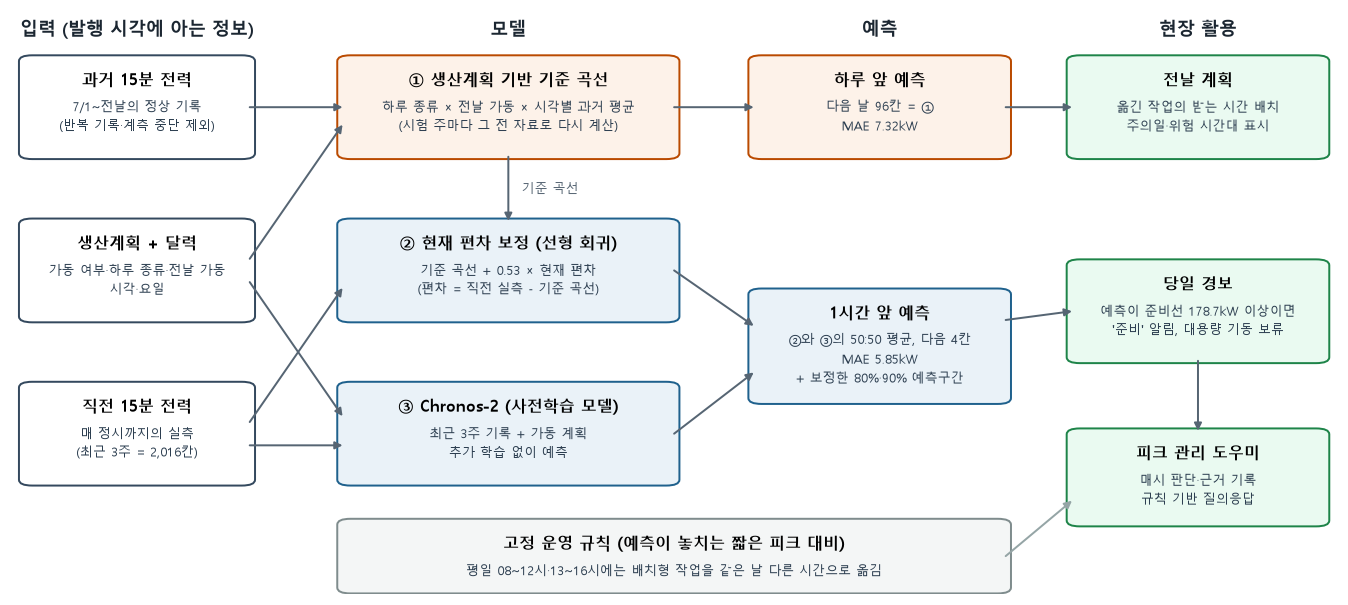

In [23]:
# 그림 31: 최종 예측·경보 구조 (입력 → 모델 → 예측 → 현장 활용)
from matplotlib.patches import FancyBboxPatch

# 그림에 넣는 숫자 (모두 위에서 계산한 값)
dev_w = a_last + a_dev                                       # 2-6: 선형 회귀의 '현재 편차' 가중치 (마지막 시험 주 직전까지 학습)
mae_day, mae_hour = mae_ci(day_all, FIN_D, "전력")[0], mae_ci(cand_hour, FIN_H, "정답")[0]
ctx_slots = 3 * 7 * 96                                       # Chronos-2 입력 길이: 최근 3주 (02-1과 같음)
l1 = 0.85 * slots.loc[(slots.index < TEST_STARTS[0]) & slots["정답사용"], "전력"].max()   # 1단계 피크 기준 (02-3)
w1 = cand_hour[cand_hour["정답사용"] & (cand_hour["시험주"] == "08/09")]
margin = min(m for m in range(21) if ((w1[FIN_H] >= l1 - m) & (w1["정답"] >= l1)).sum() / max((w1["정답"] >= l1).sum(), 1) >= 0.9)   # 02-3과 같은 규칙
ready = l1 - margin

def draw_box(ax, x, y, w, h, title, body="", fc="#ffffff", ec="#34495e"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.004,rounding_size=0.01", fc=fc, ec=ec, lw=1.3))
    ax.text(x + w / 2, y + h - 0.025, title, ha="center", va="top", fontsize=10.5, fontweight="bold")
    if body:
        ax.text(x + w / 2, y + h - 0.068, body, ha="center", va="top", fontsize=8.8, color="#2c3e50", linespacing=1.4)

def draw_arrow(ax, x0, y0, x1, y1, color="#566573"):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3, shrinkA=0, shrinkB=0))

fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
for x, t in [(0.095, "입력 (발행 시각에 아는 정보)"), (0.375, "모델"), (0.655, "예측"), (0.895, "현장 활용")]:
    ax.text(x, 0.985, t, ha="center", va="top", fontsize=11.5, fontweight="bold", color="#1b2631")

C_DAY, C_HOUR, C_OPS = "#fdf2e9", "#eaf2f8", "#eafaf1"
BOX_H = 0.17
# 입력: 위에서부터 과거 전력 / 생산계획·달력 / 직전 전력
draw_box(ax, 0.01, 0.75, 0.17, BOX_H, "과거 15분 전력", "7/1~전날의 정상 기록\n(반복 기록·계측 중단 제외)")
draw_box(ax, 0.01, 0.47, 0.17, BOX_H, "생산계획 + 달력", "가동 여부·하루 종류·전날 가동\n시각·요일")
draw_box(ax, 0.01, 0.19, 0.17, BOX_H, "직전 15분 전력", f"매 정시까지의 실측\n(최근 3주 = {ctx_slots:,}칸)")
# 모델
draw_box(ax, 0.25, 0.75, 0.25, BOX_H, "① 생산계획 기반 기준 곡선", "하루 종류 × 전날 가동 × 시각별 과거 평균\n(시험 주마다 그 전 자료로 다시 계산)", fc=C_DAY, ec="#ba4a00")
draw_box(ax, 0.25, 0.47, 0.25, BOX_H, "② 현재 편차 보정 (선형 회귀)", f"기준 곡선 + {dev_w:.2f} × 현재 편차\n(편차 = 직전 실측 - 기준 곡선)", fc=C_HOUR, ec="#1f618d")
draw_box(ax, 0.25, 0.19, 0.25, BOX_H, "③ Chronos-2 (사전학습 모델)", "최근 3주 기록 + 가동 계획\n추가 학습 없이 예측", fc=C_HOUR, ec="#1f618d")
# 예측
draw_box(ax, 0.56, 0.75, 0.19, BOX_H, "하루 앞 예측", f"다음 날 96칸 = ①\nMAE {mae_day:.2f}kW", fc=C_DAY, ec="#ba4a00")
draw_box(ax, 0.56, 0.33, 0.19, 0.19, "1시간 앞 예측", f"②와 ③의 50:50 평균, 다음 4칸\nMAE {mae_hour:.2f}kW\n+ 보정한 80%·90% 예측구간", fc=C_HOUR, ec="#1f618d")
# 현장 활용
draw_box(ax, 0.80, 0.75, 0.19, BOX_H, "전날 계획", "옮긴 작업의 받는 시간 배치\n주의일·위험 시간대 표시", fc=C_OPS, ec="#1e8449")
draw_box(ax, 0.80, 0.40, 0.19, BOX_H, "당일 경보", f"예측이 준비선 {ready:.1f}kW 이상이면\n'준비' 알림, 대용량 기동 보류", fc=C_OPS, ec="#1e8449")
draw_box(ax, 0.80, 0.12, 0.19, 0.16, "피크 관리 도우미", "매시 판단·근거 기록\n규칙 기반 질의응답", fc=C_OPS, ec="#1e8449")
draw_box(ax, 0.25, 0.005, 0.50, 0.12, "고정 운영 규칙 (예측이 놓치는 짧은 피크 대비)",
         "평일 08~12시·13~16시에는 배치형 작업을 같은 날 다른 시간으로 옮김", fc="#f4f6f6", ec="#7f8c8d")

box_mid = lambda y: y + BOX_H / 2
draw_arrow(ax, 0.18, box_mid(0.75), 0.25, box_mid(0.75))                 # 과거 전력 → ①
draw_arrow(ax, 0.18, box_mid(0.47) + 0.02, 0.25, box_mid(0.75) - 0.03)   # 계획 → ①
draw_arrow(ax, 0.18, box_mid(0.47) - 0.02, 0.25, box_mid(0.19) + 0.03)   # 계획 → ③
draw_arrow(ax, 0.18, box_mid(0.19) + 0.02, 0.25, box_mid(0.47) - 0.03)   # 직전 전력 → ②
draw_arrow(ax, 0.18, box_mid(0.19) - 0.02, 0.25, box_mid(0.19) - 0.02)   # 직전 전력 → ③
draw_arrow(ax, 0.375, 0.75, 0.375, 0.64)                                  # ① → ②
ax.text(0.385, 0.695, "기준 곡선", fontsize=8.4, color="#566573", va="center")
draw_arrow(ax, 0.50, box_mid(0.75), 0.56, box_mid(0.75)); draw_arrow(ax, 0.75, box_mid(0.75), 0.80, box_mid(0.75))
draw_arrow(ax, 0.50, box_mid(0.47), 0.56, 0.46); draw_arrow(ax, 0.50, box_mid(0.19), 0.56, 0.38)
draw_arrow(ax, 0.75, 0.47, 0.80, box_mid(0.40)); draw_arrow(ax, 0.895, 0.40, 0.895, 0.28)
draw_arrow(ax, 0.75, 0.065, 0.80, 0.16, color="#95a5a6")
print(f"그림에 넣은 값: 편차 가중치 {dev_w:.2f}, 하루 앞 MAE {mae_day:.2f}, 1시간 앞 MAE {mae_hour:.2f}, 준비선 {ready:.1f}kW (1단계 {l1:.1f} − 여유값 {margin})")
fig.tight_layout(); save_fig(fig, "f31_모델_구조"); plt.show()

## 5. 예측 결과 저장
테스트 기간(8/9~9/14) 예측 결과를 파일로 남깁니다. 대회 제출물의 '테스트 데이터 예측 결과'로 씁니다.

최종 모델의 예측은 `final_day_ahead.csv`, `final_hour_ahead.csv`에 따로 저장합니다.

In [24]:
keep_day = ["date", "시험주", "전력", "정답사용"] + DAY_MODELS
day_preds[keep_day].to_csv(PRED_DIR / "pred_day_ahead.csv", encoding="utf-8-sig")
keep_hour = ["발행시각", "대상시각", "몇번째칸", "시험주", "정답", "정답사용"] + CAND_HOUR + ["기준 곡선만", "직전 값 그대로"]
cand_hour[keep_hour].to_csv(PRED_DIR / "pred_hour_ahead.csv", encoding="utf-8-sig", index=False)

# 최종 모델 예측만 따로 저장 (제출용)
final_day = day_preds[["date", "전력", "정답사용", "③ 계획 기반 기준 곡선"]].rename(columns={"③ 계획 기반 기준 곡선": "하루앞_예측"})
final_hour = cand_hour[["발행시각", "대상시각", "몇번째칸", "정답", "정답사용", "선형 회귀 + Chronos-2 평균 (최종)"]].rename(
    columns={"정답": "전력", "선형 회귀 + Chronos-2 평균 (최종)": "1시간앞_예측"})
final_day.to_csv(PRED_DIR / "final_day_ahead.csv", encoding="utf-8-sig")
final_hour.to_csv(PRED_DIR / "final_hour_ahead.csv", encoding="utf-8-sig", index=False)
print("저장:", sorted(p.name for p in PRED_DIR.glob("*.csv")))

저장: ['chronos_day_ahead.csv', 'chronos_ft_hour_ahead.csv', 'chronos_hour_ahead.csv', 'chronos_hour_q21.csv', 'decision_log.csv', 'extra_day_ahead.csv', 'extra_hour_ahead.csv', 'final_day_ahead.csv', 'final_hour_ahead.csv', 'pred_day_ahead.csv', 'pred_hour_ahead.csv', 'test_predictions.csv']
